Song2Vec
a Music Recommender System with Word Embeddings

CS 555  LLMs: Foundations and Practice

Elif Ezgi İzgin - 38347

In [1]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 94.4 MB/s eta 0:00:00


In [2]:
import os
import json
import re
import unicodedata
from urllib.parse import unquote_plus
from collections import Counter

import pickle

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

import pickle

import logging
import time
from gensim.models import Word2Vec

import json

import time

from sklearn.manifold import TSNE

from gensim.models.callbacks import CallbackAny2Vec

from itertools import product

from typing import List

# Reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
# Mount Google Drive (required for Colab)
# If running locally, skip this cell and set BASE_PATH below accordingly.
import os

if 'COLAB_GPU' in os.environ or os.path.exists('/content'):
    from google.colab import drive
    drive.mount('/content/drive')


Mounted at /content/drive


In [4]:
# ================================================
# CONFIGURATION: Set your data path here
# ================================================
# Colab: '/content/drive/MyDrive/your_folder'
# Local: '/path/to/your/data'

BASE_PATH = "/content/drive/MyDrive/CS555_Homework_1"  # Change this to your path

PLAYLIST_FILE = os.path.join(BASE_PATH, "playlist.idomaar")
TRACKS_FILE = os.path.join(BASE_PATH, "tracks.idomaar")

print("Playlist file:", PLAYLIST_FILE)
print("Tracks file:", TRACKS_FILE)


Playlist file: /content/drive/MyDrive/CS555_Homework_1/playlist.idomaar
Tracks file: /content/drive/MyDrive/CS555_Homework_1/tracks.idomaar


In [ ]:
assert os.path.exists(PLAYLIST_FILE), f"{PLAYLIST_FILE} was not found."
assert os.path.exists(TRACKS_FILE), f"{TRACKS_FILE} was not found."

print("Both files were found successfully.")

Both files were found successfully.


In [ ]:
# File Preview - First 3 Rows

def preview_file(filepath, n=3):
    print(f"{'='*60}")
    print(f"FILE: {filepath}")
    print(f"{'='*60}")
    with open(filepath, "r", encoding="utf-8") as f:
        for i, line in enumerate(f):
            if i >= n:
                break
            # Trimming long lines to make them fit on the screen.
            print(f"[Line {i+1}]")
            parts = line.rstrip("\n").split("\t")
            for j, part in enumerate(parts):
                print(f"  col[{j}]: {part[:200]}")  # max 200 characters
            print()

preview_file(TRACKS_FILE)
preview_file(PLAYLIST_FILE)

FILE: /content/drive/MyDrive/CS555_Homework_1/tracks.idomaar
[Line 1]
  col[0]: track
  col[1]: 0
  col[2]: -1
  col[3]: {"duration":-1,"playcount":4,"MBID":null,"name":"000003+Music+Instructor/_/Dj%27s+Rock+Da+House+%C3%82%E2%89%88%C3%86%E2%89%88%C3%8A01+-+Dj+Max-Pulemet+Vs.+Bomfunk+Mc%27s+-+Electro+Breakdance+party+1+
  col[4]: {"artists":[{"type":"person","id":0}],"albums":[],"tags":[]}

[Line 2]
  col[0]: track
  col[1]: 1
  col[2]: -1
  col[3]: {"duration":-1,"playcount":495,"MBID":null,"name":"00-01/_/%D0%A2%D0%B5%D0%BA%D1%81%D1%82"}
  col[4]: {"artists":[{"type":"person","id":1}],"albums":[],"tags":[]}

[Line 3]
  col[0]: track
  col[1]: 2
  col[2]: -1
  col[3]: {"duration":-1,"playcount":2,"MBID":null,"name":"0005.+Overkill/_/Overkill"}
  col[4]: {"artists":[{"type":"person","id":2}],"albums":[],"tags":[]}

FILE: /content/drive/MyDrive/CS555_Homework_1/playlist.idomaar
[Line 1]
  col[0]: playlist
  col[1]: 0
  col[2]: 1216545588
  col[3]: {"ID":2973549,"Title":"my_favorites","n

# Part A: Data Preparation and Exploration

* **A.1 Data Loading and Preprocessing**

In [ ]:
# UNIQUE TRACK IDENTIFIER
# TRACK NAME NORMALIZATION

def normalize_text(text):
  """
  Normalize text consistently:
  - convert to lowercase
  - normalize unicode characters
  - remove extra whitespace
  - strip unnecessary punctuation at the edges
  """
  if text is None:
      return ""
  text = str(text).strip().lower()
  text = unicodedata.normalize("NFKC", text)
  text = re.sub(r"\s+", " ", text)
  text = text.strip(" -–—:;,.!?\"'`[]{}") # () removed to keep ')' sign for (remix) and (live) songs
  return text


def make_track_identifier(artist_name, track_title):
  """
  Create a unique track identifier in the format:
  artist_name__track_title
  """
  artist_name = normalize_text(artist_name)
  track_title = normalize_text(track_title)
  return f"{artist_name}__{track_title}"

In [ ]:
# PARSE TRACK FILE

def parse_tracks_file(tracks_file_path):
    """
    Read tracks.idomaar and build mappings.

    Returns:
    - trackid_to_identifier: {track_id: "artist__title"}
    - trackid_to_artist: {track_id: artist}
    - trackid_to_title: {track_id: title}
    """

    trackid_to_identifier = {}
    trackid_to_artist = {}
    trackid_to_title = {}
    bad_lines = 0

    with open(tracks_file_path, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.rstrip("\n")
            parts = line.split("\t")

            if len(parts) < 4:
                bad_lines += 1
                continue

            row_type = parts[0]
            if row_type != "track":
                continue

            try:
                track_id = int(parts[1])
                metadata = json.loads(parts[3])
                raw_name = metadata.get("name", "")
                decoded_name = unquote_plus(raw_name)

                if "/_/" in decoded_name:
                    artist, title = decoded_name.split("/_/", 1)
                else:
                    artist, title = "unknown_artist", decoded_name

                artist = normalize_text(artist)
                title = normalize_text(title)
                identifier = make_track_identifier(artist, title)

                trackid_to_identifier[track_id] = identifier
                trackid_to_artist[track_id] = artist
                trackid_to_title[track_id] = title

            except Exception as e:
                bad_lines += 1
                if bad_lines <= 5:
                    print(f"Line {line_num}: {e}")
                    print(f"  parts[1]={parts[1]}, parts[3][:100]={parts[3][:100]}")
                continue

    print(f"Parsed track count: {len(trackid_to_identifier):,}")
    print(f"Skipped malformed lines: {bad_lines:,}")

    return trackid_to_identifier, trackid_to_artist, trackid_to_title

trackid_to_identifier, trackid_to_artist, trackid_to_title = parse_tracks_file(TRACKS_FILE)

Parsed track count: 4,519,105
Skipped malformed lines: 0


In [ ]:
# CONVERT PLAYLISTS TO SENTENCES
def parse_playlists_file(playlist_file_path, trackid_to_identifier, min_playlist_len=2):
  """
  Parse playlist.idomaar and convert each playlist into a sentence —
  an ordered list of track identifiers — suitable for Word2Vec training.
  Track IDs not found in trackid_to_identifier are counted and skipped.
  Playlists shorter than min_playlist_len after filtering are discarded.

  Returns:
      playlists_as_sentences : list[list[str]]
  """
  playlists_as_sentences = []

  skipped_no_tracks = 0
  skipped_too_short = 0
  skipped_malformed = 0
  unknown_track_count = 0  # track IDs that are not in tracks.idomaar

  with open(playlist_file_path, "r", encoding="utf-8") as f:
      for line_num, line in enumerate(f, start=1):
          line = line.rstrip("\n")
          parts = line.split("\t")

          if len(parts) < 5:
              skipped_malformed += 1
              continue

          row_type = parts[0]
          if row_type != "playlist":
              continue

          try:
              subj_obj = json.loads(parts[4])
              objects = subj_obj.get("objects", [])

              track_ids = []
              for obj in objects:
                if not isinstance(obj, dict):  # empty list or unexpected type
                    continue
                if obj.get("type") == "track":
                    tid = obj.get("id")
                    if tid in trackid_to_identifier:
                        track_ids.append(tid)
                    else:
                        unknown_track_count += 1

              if len(track_ids) == 0:
                  skipped_no_tracks += 1
                  continue

              sentence = [trackid_to_identifier[tid] for tid in track_ids]

              if len(sentence) < min_playlist_len:
                  skipped_too_short += 1
                  continue

              playlists_as_sentences.append(sentence)

          except Exception:
              skipped_malformed += 1
              continue

  print(f"Parsed playlist count        : {len(playlists_as_sentences):,}")
  print(f"Skipped - no valid tracks    : {skipped_no_tracks:,}")
  print(f"Skipped - too short          : {skipped_too_short:,}")
  print(f"Skipped - malformed rows     : {skipped_malformed:,}")
  print(f"Unknown track ID references  : {unknown_track_count:,}")

  return playlists_as_sentences


playlists_as_sentences = parse_playlists_file(
    PLAYLIST_FILE,
    trackid_to_identifier,
    min_playlist_len=2
)

Parsed playlist count        : 47,130
Skipped - no valid tracks    : 9,139
Skipped - too short          : 1,292
Skipped - malformed rows     : 0
Unknown track ID references  : 0


In [ ]:
# Save playlists_as_sentences
SAVE_PATH = os.path.join(BASE_PATH, "playlists_as_sentences.pkl")

with open(SAVE_PATH, "wb") as f:
    pickle.dump(playlists_as_sentences, f)

print(f"Saved to: {SAVE_PATH}")

Saved to: /content/drive/MyDrive/CS555_Homework_1/playlists_as_sentences.pkl


In [5]:
# Reload playlists_as_sentences
SAVE_PATH = os.path.join(BASE_PATH, "playlists_as_sentences.pkl")

with open(SAVE_PATH, "rb") as f:
    playlists_as_sentences = pickle.load(f)

print(f"Loaded: {len(playlists_as_sentences):,} playlists")

Loaded: 47,130 playlists


In [ ]:
# OPTIONAL: Debug version of parse_playlists_file
# Shows examples of discarded playlists (no valid tracks / too short).
# Run this cell only for exploratory analysis.

def parse_playlists_file_debug(playlist_file_path, trackid_to_identifier, 
                                min_playlist_len=2, max_examples=3):
    """
    Debug version of parse_playlists_file.
    Logs examples of discarded playlists for inspection.
    """
    playlists_as_sentences = []
    skipped_no_tracks = 0
    skipped_too_short = 0
    skipped_malformed = 0
    unknown_track_count = 0
    no_tracks_examples = []
    too_short_examples = []

    with open(playlist_file_path, "r", encoding="utf-8") as f:
        for line_num, line in enumerate(f, start=1):
            line = line.rstrip("\n")
            parts = line.split("\t")
            if len(parts) < 5:
                skipped_malformed += 1
                continue
            if parts[0] != "playlist":
                continue
            try:
                subj_obj = json.loads(parts[4])
                objects = subj_obj.get("objects", [])
                track_ids = []
                for obj in objects:
                    if not isinstance(obj, dict):
                        continue
                    if obj.get("type") == "track":
                        tid = obj.get("id")
                        if tid in trackid_to_identifier:
                            track_ids.append(tid)
                        else:
                            unknown_track_count += 1
                if len(track_ids) == 0:
                    skipped_no_tracks += 1
                    if len(no_tracks_examples) < max_examples:
                        no_tracks_examples.append({"line": line_num, "objects": objects[:5]})
                    continue
                sentence = [trackid_to_identifier[tid] for tid in track_ids]
                if len(sentence) < min_playlist_len:
                    skipped_too_short += 1
                    if len(too_short_examples) < max_examples:
                        too_short_examples.append({"line": line_num, "sentence": sentence})
                    continue
                playlists_as_sentences.append(sentence)
            except Exception:
                skipped_malformed += 1
                continue

    print(f"Parsed playlist count        : {len(playlists_as_sentences):,}")
    print(f"Skipped - no valid tracks    : {skipped_no_tracks:,}")
    print(f"Skipped - too short          : {skipped_too_short:,}")
    print(f"Skipped - malformed rows     : {skipped_malformed:,}")
    print(f"Unknown track ID references  : {unknown_track_count:,}")
    print(f"\n--- No valid tracks examples ---")
    for ex in no_tracks_examples:
        print(f"  Line {ex['line']}: objects={ex['objects']}")
    print(f"\n--- Too short examples ---")
    for ex in too_short_examples:
        print(f"  Line {ex['line']}: sentence={ex['sentence']}")

    return playlists_as_sentences


Parsed playlist count        : 47,130
Skipped - no valid tracks    : 9,139
Skipped - too short          : 1,292
Skipped - malformed rows     : 0
Unknown track ID references  : 0

--- No valid tracks examples ---
  Line 11: objects=[[]]
  Line 20: objects=[]
  Line 21: objects=[]

--- Too short examples ---
  Line 19: sentence=['kill hannah__unwanted']
  Line 61: sentence=['you fantastic__riddler 5']
  Line 92: sentence=['luis fonsi__llueve por dentro']


In [ ]:
# DATASET STATISTICS
all_playlists_raw = parse_playlists_file(
    PLAYLIST_FILE,
    trackid_to_identifier,
    min_playlist_len=1
)

total_listening_events = sum(len(pl) for pl in all_playlists_raw)
unique_tracks = len(set(track for pl in all_playlists_raw for track in pl))
unique_artists = len(set(track.split("__")[0] for pl in all_playlists_raw for track in pl))

print(f"Total playlists        : {len(all_playlists_raw):,}")
print(f"Total listening events : {total_listening_events:,}")
print(f"Unique tracks          : {unique_tracks:,}")
print(f"Unique artists         : {unique_artists:,}")

Parsed playlist count        : 48,422
Skipped - no valid tracks    : 9,139
Skipped - too short          : 0
Skipped - malformed rows     : 0
Unknown track ID references  : 0
Total playlists        : 48,422
Total listening events : 1,603,040
Unique tracks          : 443,569
Unique artists         : 60,282


In [ ]:
# Check whether the last song have a duplicate in the playlist.
duplicate_count = 0
total_checked = 0

for playlist in playlists_as_sentences:
    if len(playlist) < 2:
        continue
    true_item = playlist[-1]
    context = playlist[:-1]
    if true_item in context:
        duplicate_count += 1
    total_checked += 1

print(f"Total checked         : {total_checked:,}")
print(f"Duplicate true items  : {duplicate_count:,}")
print(f"Duplicate ratio       : {100 * duplicate_count / total_checked:.2f}%")

Total checked         : 47,130
Duplicate true items  : 641
Duplicate ratio       : 1.36%


In [ ]:
# SAMPLE OUTPUT CHECK
print("Example playlist:")
print(playlists_as_sentences[0][:10])

print("\nExample track identifier:")
print(playlists_as_sentences[0][0])

Example playlist:
['the whip__trash (crookers remix)', 'modeselektor__sucker pin', 'simian mobile disco__hustler', 'gossip__standing in the way of control', 'kalwi & remi__explosion (dj theo remix)', 'jackson and his computer band__arpeggio', 'midnight juggernauts__into the galaxy', "klaxons__it's not over yet", 'yeah yeah yeahs__maps', 'radiohead__true love waits (live)']

Example track identifier:
the whip__trash (crookers remix)


In [ ]:
# TRAIN / TEST SPLIT
train_playlists, test_playlists = train_test_split(
    playlists_as_sentences,
    test_size=0.20,
    random_state=RANDOM_SEED,
    shuffle=True
)

print(f"Total playlists : {len(playlists_as_sentences):,}")
print(f"Train playlists : {len(train_playlists):,}")
print(f"Test playlists  : {len(test_playlists):,}")

Total playlists : 47,130
Train playlists : 37,704
Test playlists  : 9,426


In [ ]:
# SAVE PROCESSED DATA
processed_data = {
    "train_playlists": train_playlists,
    "test_playlists": test_playlists,
    "all_playlists": playlists_as_sentences,
    "track_counter": track_counter,
    "artist_counter": artist_counter,
    "trackid_to_identifier": trackid_to_identifier,
    "trackid_to_artist": trackid_to_artist,
    "trackid_to_title": trackid_to_title,
    "random_seed": RANDOM_SEED
}

SAVE_PATH = os.path.join(BASE_PATH, "partA_processed_data.pkl")

with open(SAVE_PATH, "wb") as f:
    pickle.dump(processed_data, f)

print(f"Processed data was saved to: {SAVE_PATH}")

Processed data was saved to: /content/drive/MyDrive/CS555_Homework_1/partA_processed_data.pkl


In [6]:
# RELOAD PROCESSED DATA

SAVE_PATH = os.path.join(BASE_PATH, "partA_processed_data.pkl")

with open(SAVE_PATH, "rb") as f:
    processed_data = pickle.load(f)

train_playlists = processed_data["train_playlists"]
test_playlists = processed_data["test_playlists"]
playlists_as_sentences = processed_data["all_playlists"]
track_counter = processed_data["track_counter"]
artist_counter = processed_data["artist_counter"]
trackid_to_identifier = processed_data["trackid_to_identifier"]
trackid_to_artist = processed_data["trackid_to_artist"]
trackid_to_title = processed_data["trackid_to_title"]
RANDOM_SEED = processed_data["random_seed"]

print("Data loaded successfully.")
print(f"Train playlists : {len(train_playlists):,}")
print(f"Test playlists  : {len(test_playlists):,}")

Data loaded successfully.
Train playlists : 37,704
Test playlists  : 9,426


* **A.2 Exploratory Data Analysis**

Minimum playlist length : 2
Maximum playlist length : 200
Average playlist length : 33.99
Median playlist length  : 15.00


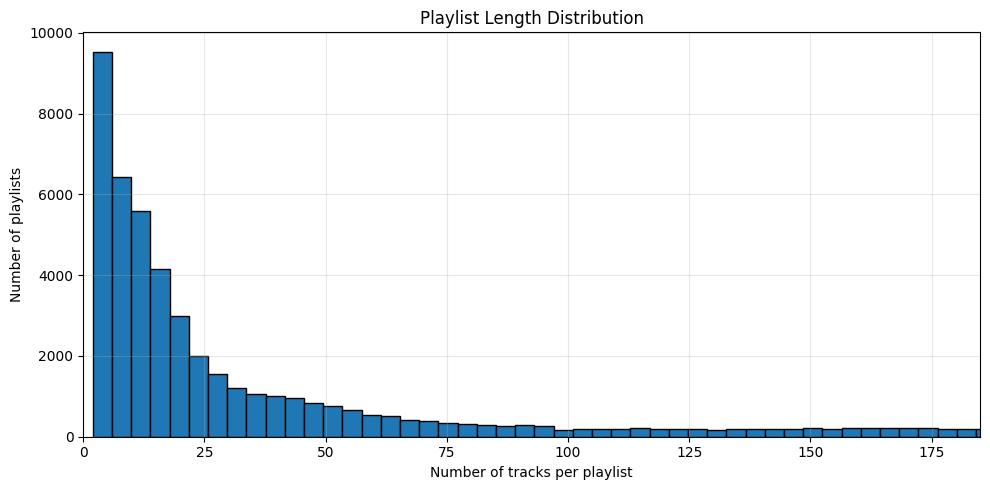

In [ ]:
# PLAYLIST LENGTH DISTRIBUTION

playlist_lengths = [len(pl) for pl in playlists_as_sentences]

print(f"Minimum playlist length : {np.min(playlist_lengths)}")
print(f"Maximum playlist length : {np.max(playlist_lengths)}")
print(f"Average playlist length : {np.mean(playlist_lengths):.2f}")
print(f"Median playlist length  : {np.median(playlist_lengths):.2f}")

plt.figure(figsize=(10, 5))
plt.xlim(0, np.percentile(playlist_lengths, 99))  # crop top %1
plt.hist(playlist_lengths, bins=50, edgecolor="black")
plt.title("Playlist Length Distribution")
plt.xlabel("Number of tracks per playlist")
plt.ylabel("Number of playlists")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "playlist_length_dist.pdf"), dpi=300, bbox_inches="tight")
plt.show()

Total track occurrences: 1,601,748
Number of unique tracks: 443,184


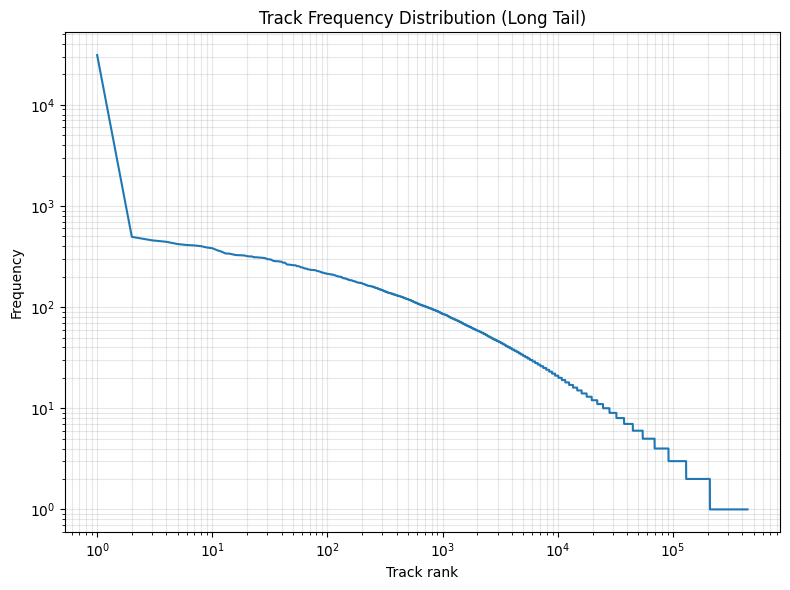

In [7]:
# TRACK FREQUENCY DISTRIBUTION

# Flatten all playlists into a single list of tracks
all_tracks = [track for playlist in playlists_as_sentences for track in playlist]

# Count how many times each track appears
track_counter = Counter(all_tracks)

# Sort frequencies from highest to lowest
track_frequencies = sorted(track_counter.values(), reverse=True)

# Rank values
ranks = np.arange(1, len(track_frequencies) + 1)

print(f"Total track occurrences: {sum(track_frequencies):,}")
print(f"Number of unique tracks: {len(track_frequencies):,}")

plt.figure(figsize=(8, 6))
plt.loglog(ranks, track_frequencies)
plt.title("Track Frequency Distribution (Long Tail)")
plt.xlabel("Track rank")
plt.ylabel("Frequency")
plt.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "track_freq_dist.pdf"), dpi=300, bbox_inches="tight")
plt.show()

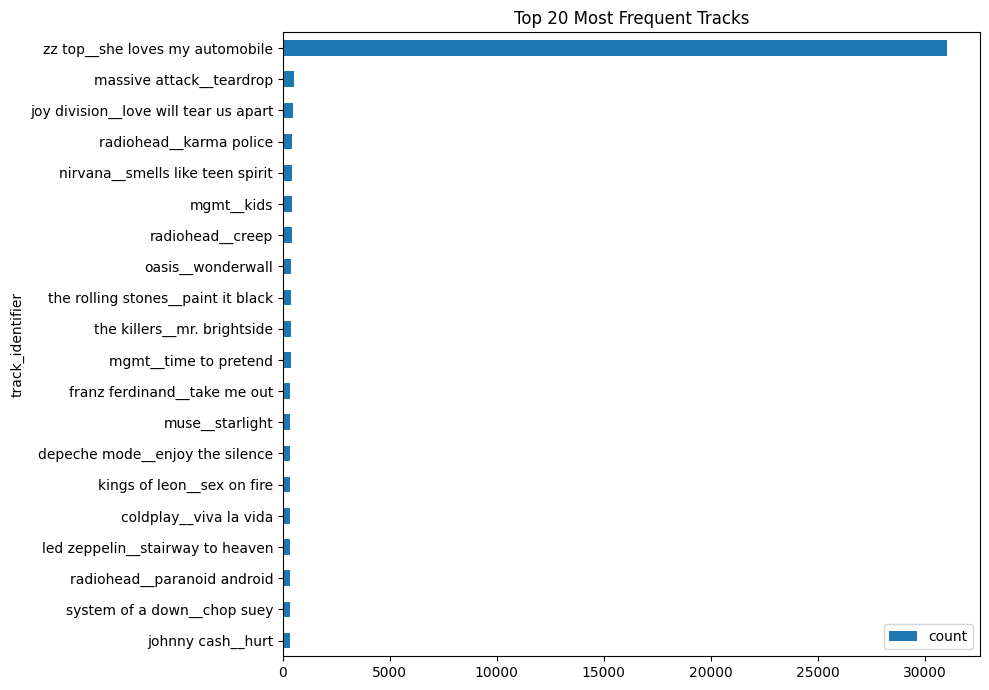

In [ ]:
# TOP 20 TRACKS
top_20_tracks = track_counter.most_common(20)
top_tracks_df = pd.DataFrame(top_20_tracks, columns=["track_identifier", "count"])

top_tracks_df.plot(kind="barh", x="track_identifier", y="count", figsize=(10, 7))
plt.title("Top 20 Most Frequent Tracks")
plt.gca().invert_yaxis()
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "top20_tracks.pdf"), dpi=300, bbox_inches="tight")
plt.show()

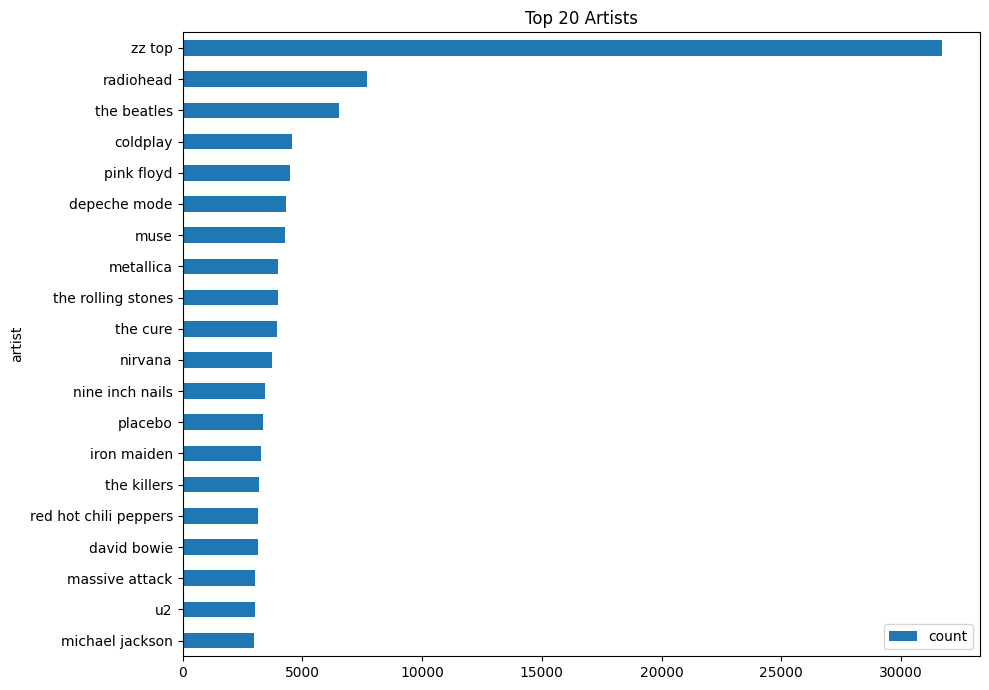

In [ ]:
# TOP 20 Artists
artist_counter = Counter()

for track_id, count in track_counter.items():
    # Format: artist__title
    artist = track_id.split("__", 1)[0]
    artist_counter[artist] += count

top_20_artists = artist_counter.most_common(20)

top_artists_df = pd.DataFrame(top_20_artists, columns=["artist", "count"])
top_artists_df

top_artists_df.plot(kind="barh", x="artist", y="count", figsize=(10, 7))
plt.title("Top 20 Artists")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "top20_artists.pdf"), dpi=300, bbox_inches="tight")
plt.show()

In [18]:
#  VOCABULARY STATISTICS
total_unique_tracks = len(track_counter)

# Tracks that appear only once
hapax_count = sum(1 for c in track_counter.values() if c == 1)

# Total number of track occurrences
total_track_occurrences = sum(track_counter.values())

print("Vocabulary Statistics")
print("-" * 40)
print(f"Total unique tracks            : {total_unique_tracks:,}")
print(f"Tracks appearing only once     : {hapax_count:,}")
print(f"Hapax percentage               : {100 * hapax_count / total_unique_tracks:.2f}%")
print(f"Total track occurrences        : {total_track_occurrences:,}")

Vocabulary Statistics
----------------------------------------
Total unique tracks            : 443,184
Tracks appearing only once     : 234,334
Hapax percentage               : 52.88%
Total track occurrences        : 1,601,748


In [19]:
# COVERAGE ANALYSIS

for threshold in [1, 3, 5, 10]:
    tracks_above_threshold = {
        track: count for track, count in track_counter.items() if count >= threshold
    }

    type_coverage = len(tracks_above_threshold) / total_unique_tracks * 100
    token_coverage = sum(tracks_above_threshold.values()) / total_track_occurrences * 100

    print(f"\nFor min_count >= {threshold}:")
    print(f"Vocab size     : {len(tracks_above_threshold):,}")
    print(f"Type coverage  : {type_coverage:.2f}%")
    print(f"Token coverage : {token_coverage:.2f}%")


For min_count >= 1:
Vocab size     : 443,184
Type coverage  : 100.00%
Token coverage : 100.00%

For min_count >= 3:
Vocab size     : 129,854
Type coverage  : 29.30%
Token coverage : 75.51%

For min_count >= 5:
Vocab size     : 69,140
Type coverage  : 15.60%
Token coverage : 62.75%

For min_count >= 10:
Vocab size     : 28,048
Type coverage  : 6.33%
Token coverage : 46.38%


In [ ]:
# SUMMARY TABLE
summary_stats = {
    "num_playlists": len(playlists_as_sentences),
    "num_train_playlists": len(train_playlists),
    "num_test_playlists": len(test_playlists),
    "avg_playlist_length": np.mean(playlist_lengths),
    "median_playlist_length": np.median(playlist_lengths),
    "max_playlist_length": np.max(playlist_lengths),
    "total_unique_tracks": total_unique_tracks,
    "hapax_legomena": hapax_count,
    "hapax_percentage": 100 * hapax_count / total_unique_tracks,
    "total_unique_artists": len(artist_counter),
}

summary_df = pd.DataFrame([summary_stats]).T
summary_df.columns = ["value"]

pd.options.display.float_format = '{:.0f}'.format
summary_df

,value
num_playlists,47130
num_train_playlists,37704
num_test_playlists,9426
avg_playlist_length,34
median_playlist_length,15
max_playlist_length,200
total_unique_tracks,443184
hapax_legomena,234334
hapax_percentage,53
total_unique_artists,60134


In [ ]:
# PIPELINE SANITY CHECK
# Verifies that track IDs in playlist.idomaar correctly map to identifiers.

with open(PLAYLIST_FILE, "r", encoding="utf-8") as f:
    first_line = f.readline().rstrip("\n")

parts = first_line.split("\t")
subj_obj = json.loads(parts[4])
first_track_ids = [obj["id"] for obj in subj_obj["objects"] if obj["type"] == "track"][:3]

print("First 3 track IDs of Playlist 0:", first_track_ids)
print()

for tid in first_track_ids:
    identifier = trackid_to_identifier.get(tid, "NOT FOUND")
    print(f"  ID {tid:>8} → {identifier}")


Playlist 0'ın ilk 3 track ID'si: [3006631, 1885124, 2548942]

  ID  3006631 → the whip__trash (crookers remix)
  ID  1885124 → modeselektor__sucker pin
  ID  2548942 → simian mobile disco__hustler


In [ ]:
# Verify a specific track ID mapping (optional)
# print(trackid_to_identifier.get(3006631, 'NOT FOUND'))

the whip__trash (crookers remix)


# Part B: Song2Vec Model Training

* **B.1 Baseline Model**

In [ ]:
class LossCallback(CallbackAny2Vec):
    def __init__(self):
        self.epoch = 0
        self.loss_history = []
        self.prev_loss = 0

    def on_epoch_end(self, model):
        loss = model.get_latest_training_loss()
        epoch_loss = loss - self.prev_loss
        self.prev_loss = loss
        self.loss_history.append(epoch_loss)
        print(f"  Epoch {self.epoch + 1}: loss = {epoch_loss:.4f}")
        self.epoch += 1


def train_with_logs(config, train_playlists, label="model"):
    callback = LossCallback()
    start_time = time.time()

    model = Word2Vec(
        sentences=train_playlists,
        compute_loss=True,
        callbacks=[callback],
        **config
    )

    train_time = time.time() - start_time

    log = {
        "label":         label,
        "config":        {k: v for k, v in config.items()},
        "train_time":    round(train_time, 2),
        "loss_history":  callback.loss_history,
        "final_loss":    round(callback.loss_history[-1], 4) if callback.loss_history else None,
        "vocab_size":    len(model.wv),
        "timestamp":     time.strftime("%Y-%m-%d %H:%M:%S")
    }

    print(f"Training time : {train_time:.1f}s")
    print(f"Vocab size    : {len(model.wv):,}")

    return model, log

In [ ]:
# Baseline config
BASELINE_CONFIG = {
    "vector_size": 100,
    "window": 5,
    "min_count": 5,
    "sg": 1,
    "negative": 5,
    "ns_exponent": 0.75,
    "workers": 4,
    "epochs": 5,
    "seed": RANDOM_SEED
}

In [ ]:
# List for training logs
training_logs = []

# Log the Baseline model
baseline_model, baseline_log = train_with_logs(BASELINE_CONFIG, train_playlists, label="baseline_model")
training_logs.append(baseline_log)

# Save Logs
LOG_PATH = os.path.join(BASE_PATH, "baseline_training_logs.json")
with open(LOG_PATH, "w") as f:
    json.dump(training_logs, f, indent=2)

print(f"\nLogs saved to: {LOG_PATH}")

  Epoch 1: loss = 4238976.5000
  Epoch 2: loss = 3192400.0000
  Epoch 3: loss = 2122152.5000
  Epoch 4: loss = 1783674.0000
  Epoch 5: loss = 1704917.0000
Training time : 36.1s
Vocab size    : 54,651

Logs saved to: /content/drive/MyDrive/CS555_Homework_1/baseline_training_logs.json


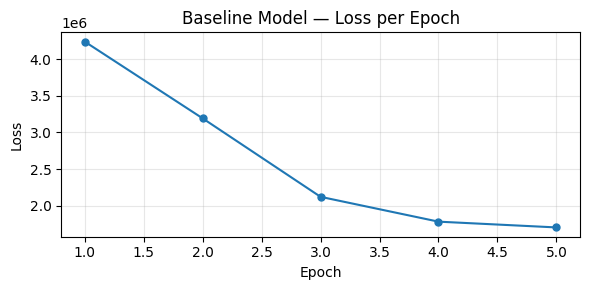

In [5]:
with open(os.path.join(BASE_PATH, "baseline_training_logs.json"), "r") as f:
    baseline_logs = json.load(f)

loss_history = baseline_logs[0]["loss_history"]

plt.figure(figsize=(6, 3))
plt.plot(range(1, len(loss_history) + 1), loss_history, marker="o", markersize=5)
plt.title("Baseline Model — Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "baseline_loss.pdf"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Save the baseline model
baseline_model.save(os.path.join(BASE_PATH, "baseline_model.model"))

In [25]:
# Reload the baseline model
baseline_model = Word2Vec.load(os.path.join(BASE_PATH, "baseline_model.model"))

In [ ]:
# The most frequent track's vector
most_common_track = track_counter.most_common(1)[0][0]
print(f"Track: {most_common_track}")
print(f"Vector norm: {np.linalg.norm(baseline_model.wv[most_common_track]):.4f}")

Track: zz top__she loves my automobile
Vector norm: 3.7117


In [ ]:
# Similar tracks to the most frequent track in Vocabulary
print(baseline_model.wv.most_similar(most_common_track, topn=5))

[('claude debussy__clair de lune', 0.5117212533950806), ('arvo pärt__spiegel im spiegel', 0.49388962984085083), ('secret garden__nocturne', 0.4868197739124298), ('franz liszt__la campanella', 0.48657411336898804), ('johann sebastian bach__toccata and fugue in d minor', 0.48597341775894165)]


In [ ]:
# A popular track  and top 5 similar tracks
print(baseline_model.wv.most_similar("radiohead__creep", topn=5))

[('radiohead__karma police', 0.9686723351478577), ('radiohead__paranoid android', 0.9632370471954346), ('radiohead__just', 0.9570805430412292), ('radiohead__no surprises', 0.9542827606201172), ('radiohead__fake plastic trees', 0.9498680830001831)]


*   **Evaluation Metrics**

* The section below compares filtered and unfiltered evaluation approaches. In the filtered version, context songs are excluded from the recommendation list. However, since 1.36% of playlists contain the true last song as a duplicate within the context, filtering artificially lowers HR@K by removing the correct answer. Unfiltered evaluation is therefore adopted from this point onward.

In [ ]:
def hit_rate_at_k(recommendations, true_item):
    """
    Returns 1.0 if true_item is in the recommendations list, else 0.0.
    """
    return 1.0 if true_item in recommendations else 0.0


def ndcg_at_k(recommendations, true_item):
    """
    Returns NDCG@K for a single query.
    If true_item is found at position i (0-indexed), score = 1 / log2(i + 2).
    If not found, score = 0.
    """
    if true_item in recommendations:
        rank = recommendations.index(true_item)  # 0-indexed
        return 1.0 / np.log2(rank + 2)
    return 0.0

def evaluate_model(model, test_playlists, k_values=[5, 10, 20, 50], approach="context", filter_context=True):
    results = {k: {"HR": [], "NDCG": []} for k in k_values}
    skipped = 0

    for playlist in test_playlists:
        if len(playlist) < 2:
            skipped += 1
            continue

        context = playlist[:-1]
        true_item = playlist[-1]

        if true_item not in model.wv:
            skipped += 1
            continue

        if approach == "context":
            context_in_vocab = [s for s in context if s in model.wv]
            if not context_in_vocab:
                skipped += 1
                continue
            context_vector = np.mean(
                [model.wv[s] for s in context_in_vocab], axis=0
            )
            topn = max(k_values) + len(context) if filter_context else max(k_values)
            similar = model.wv.similar_by_vector(context_vector, topn=topn)

        elif approach == "single":
            query_song = context[-1]
            if query_song not in model.wv:
                skipped += 1
                continue
            topn = max(k_values) + len(context) if filter_context else max(k_values)
            similar = model.wv.most_similar(query_song, topn=topn)

        if filter_context:
            recommendations = [song for song, score in similar if song not in context]
        else:
            recommendations = [song for song, score in similar]

        for k in k_values:
            top_k = recommendations[:k]
            results[k]["HR"].append(hit_rate_at_k(top_k, true_item))
            results[k]["NDCG"].append(ndcg_at_k(top_k, true_item))

    summary = {}
    for k in k_values:
        summary[k] = {
            "HR":   np.mean(results[k]["HR"]),
            "NDCG": np.mean(results[k]["NDCG"])
        }

    print(f"Skipped: {skipped:,} / {len(test_playlists):,}")
    return summary

def print_results(summary, approach_name):
  print(f"\n{'='*45}")
  print(f" {approach_name}")
  print(f"{'='*45}")
  print(f"{'K':<6} {'HR@K':<12} {'NDCG@K':<12}")
  print(f"{'-'*30}")
  for k, metrics in summary.items():
      print(f"{k:<6} {metrics['HR']:<12.4f} {metrics['NDCG']:<12.4f}")

In [ ]:
# EVALUATION: CONTEXT FILTERING COMPARISON

# Approach 1: Remove Context songs from recommendation
ctx_filtered = evaluate_model(baseline_model, test_playlists, k_values=[5, 10, 20, 50], approach="context", filter_context=True)
sng_filtered = evaluate_model(baseline_model, test_playlists, k_values=[5, 10, 20, 50], approach="single", filter_context=True)

# Approach 2: Keep Context songs in recommendation
ctx_unfiltered = evaluate_model(baseline_model, test_playlists, k_values=[5, 10, 20, 50], approach="context", filter_context=False)
sng_unfiltered = evaluate_model(baseline_model, test_playlists, k_values=[5, 10, 20, 50], approach="single", filter_context=False)

print_results(ctx_filtered,   "Context Averaging | filtered")
print_results(sng_filtered,   "Single Query       | filtered")
print_results(ctx_unfiltered, "Context Averaging  | unfiltered")
print_results(sng_unfiltered, "Single Query       | unfiltered")

Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426

 Context Averaging | filtered
K      HR@K         NDCG@K      
------------------------------
5      0.0096       0.0057      
10     0.0173       0.0081      
20     0.0263       0.0104      
50     0.0404       0.0133      

 Single Query       | filtered
K      HR@K         NDCG@K      
------------------------------
5      0.0254       0.0174      
10     0.0378       0.0213      
20     0.0512       0.0247      
50     0.0716       0.0288      

 Context Averaging  | unfiltered
K      HR@K         NDCG@K      
------------------------------
5      0.0166       0.0138      
10     0.0249       0.0164      
20     0.0350       0.0190      
50     0.0503       0.0220      

 Single Query       | unfiltered
K      HR@K         NDCG@K      
------------------------------
5      0.0214       0.0143      
10     0.0331       0.0181      
20     0.0502       0.0224      
50     0.0706       0.0265

* Discarded section ends here.

In [11]:
# EVALUATION METRICS
def hit_rate_at_k(recommendations, true_item):
    """
    Returns 1.0 if true_item is in the recommendations list, else 0.0.
    """
    return 1.0 if true_item in recommendations else 0.0


def ndcg_at_k(recommendations, true_item):
    """
    Returns NDCG@K for a single query.
    If true_item is found at position i (0-indexed), score = 1 / log2(i + 2).
    If not found, score = 0.
    """
    if true_item in recommendations:
        rank = recommendations.index(true_item)  # 0-indexed
        return 1.0 / np.log2(rank + 2)
    return 0.0


def evaluate_model(model, test_playlists, k_values=[5, 10, 20, 50], approach="context"):
    """
    Evaluate a Word2Vec model on next-song prediction.

    approach="context" : uses average of all N-1 songs as query (Our Approach)
    approach="single"  : uses only the (N-1)th song as query (Paper Approach)

    Returns a dict of {k: {"HR": float, "NDCG": float}}
    """
    results = {k: {"HR": [], "NDCG": []} for k in k_values}
    skipped = 0

    for playlist in test_playlists:
        if len(playlist) < 2:
            skipped += 1
            continue

        context = playlist[:-1]   # all but last
        true_item = playlist[-1]  # last song to predict

        # Skip if true_item not in vocabulary
        if true_item not in model.wv:
            skipped += 1
            continue

        if approach == "context":
            # Filter context songs that are in vocabulary
            context_in_vocab = [s for s in context if s in model.wv]
            if not context_in_vocab:
                skipped += 1
                continue
            # Average embedding of context songs
            context_vector = np.mean(
                [model.wv[s] for s in context_in_vocab], axis=0
            )
            similar = model.wv.similar_by_vector(
                context_vector, topn=max(k_values)
            )

        elif approach == "single":
            # Use only the second-to-last song
            query_song = context[-1]
            if query_song not in model.wv:
                skipped += 1
                continue
            similar = model.wv.most_similar(
                query_song, topn=max(k_values)
            )

        recommendations = [song for song, score in similar]

        for k in k_values:
            top_k = recommendations[:k]
            results[k]["HR"].append(hit_rate_at_k(top_k, true_item))
            results[k]["NDCG"].append(ndcg_at_k(top_k, true_item))

    # Average over all test cases
    summary = {}
    for k in k_values:
        summary[k] = {
            "HR":   np.mean(results[k]["HR"]),
            "NDCG": np.mean(results[k]["NDCG"])
        }

    print(f"Skipped: {skipped:,} / {len(test_playlists):,}")
    return summary


def print_results(summary, approach_name):
    print(f"\n{'='*45}")
    print(f" {approach_name}")
    print(f"{'='*45}")
    print(f"{'K':<6} {'HR@K':<12} {'NDCG@K':<12}")
    print(f"{'-'*30}")
    for k, metrics in summary.items():
        print(f"{k:<6} {metrics['HR']:<12.4f} {metrics['NDCG']:<12.4f}")

In [ ]:
context_results = evaluate_model(baseline_model, test_playlists, approach="context")
print_results(context_results, "Approach 1: Context Averaging")

print()

single_results = evaluate_model(baseline_model, test_playlists, approach="single")
print_results(single_results, "Approach 2: Single Query Song")

Skipped: 4,970 / 9,426

 Approach 1: Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0166       0.0138      
10     0.0249       0.0164      
20     0.0350       0.0190      
50     0.0503       0.0220      

Skipped: 6,436 / 9,426

 Approach 2: Single Query Song
K      HR@K         NDCG@K      
------------------------------
5      0.0214       0.0143      
10     0.0331       0.0181      
20     0.0502       0.0224      
50     0.0706       0.0265      


* **Note:** Single Query approach consistently outperforms Context Averaging across all K values. See Section 3.5 in the report for analysis.

* **B.2 Hyperparameter Experiments**

In [ ]:
# HYPERPARAMETER EXPERIMENTS

# Baseline config
BASELINE_CONFIG = {
    "vector_size": 100,
    "window": 5,
    "min_count": 5,
    "sg": 1,
    "negative": 5,
    "ns_exponent": 0.75,
    "workers": 4,
    "epochs": 5,
    "seed": RANDOM_SEED
}

def train_and_evaluate(config, train_playlists, test_playlists, k_values=[5, 10, 20, 50]):
    start = time.time()
    model = Word2Vec(sentences=train_playlists, **config)
    train_time = round(time.time() - start, 1)

    results_context = evaluate_model(model, test_playlists, k_values, approach="context")
    results_single  = evaluate_model(model, test_playlists, k_values, approach="single")
    return model, results_context, results_single, train_time

In [ ]:
# sg EXPERIMENT: 0 (CBOW) vs 1 (Skip-gram)

sg_results = {}

for sg_val in [0, 1]:
    print(f"\nTraining sg={sg_val} ({'CBOW' if sg_val == 0 else 'Skip-gram'})...")
    config = {**BASELINE_CONFIG, "sg": sg_val}
    model, ctx, sng, train_time = train_and_evaluate(config, train_playlists, test_playlists)
    sg_results[sg_val] = {"context": ctx, "single": sng, "train_time": train_time}
    print(f"Train time: {train_time}s")
    print_results(ctx, f"sg={sg_val} | Context Averaging")
    print_results(sng, f"sg={sg_val} | Single Query")


Training sg=0 (CBOW)...
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Train time: 10.2s

 sg=0 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0175       0.0151      
10     0.0200       0.0159      
20     0.0231       0.0167      
50     0.0307       0.0182      

 sg=0 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0057       0.0044      
10     0.0087       0.0053      
20     0.0104       0.0058      
50     0.0184       0.0073      

Training sg=1 (Skip-gram)...
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Train time: 27.9s

 sg=1 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0182       0.0150      
10     0.0258       0.0174      
20     0.0368       0.0202      
50     0.0523       0.0233      

 sg=1 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0227       0.0134      
10     0.0355       0.0175      
2

In [ ]:
# window EXPERIMENT: 5, 10, 20, 40

window_results = {}

for window_val in [5, 10, 20, 40]:
    print(f"\nTraining window={window_val}...")
    config = {**BASELINE_CONFIG, "window": window_val}
    model, ctx, sng, train_time = train_and_evaluate(config, train_playlists, test_playlists)
    window_results[window_val]  = {"context": ctx, "single": sng, "train_time": train_time}
    print(f"Train time: {train_time}s")

    print_results(ctx, f"window={window_val} | Context Averaging")
    print_results(sng, f"window={window_val} | Single Query")


Training window=5...
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Train time: 26.1s

 window=5 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0191       0.0155      
10     0.0245       0.0173      
20     0.0357       0.0201      
50     0.0503       0.0230      

 window=5 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0224       0.0136      
10     0.0375       0.0184      
20     0.0542       0.0226      
50     0.0699       0.0257      

Training window=10...
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Train time: 41.9s

 window=10 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0209       0.0175      
10     0.0296       0.0203      
20     0.0442       0.0240      
50     0.0709       0.0292      

 window=10 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0268       0.0171      
10     0.0485       0.0241

In [ ]:
# negative EXPERIMENT: 5, 10, 15, 20

negative_results = {}

for negative_val in [5, 10, 15, 20]:
    print(f"\nTraining negative={negative_val}...")
    config = {**BASELINE_CONFIG, "negative": negative_val}
    model, ctx, sng, train_time = train_and_evaluate(config, train_playlists, test_playlists)
    negative_results[negative_val] = {"context": ctx, "single": sng, "train_time": train_time}
    print(f"Train time: {train_time}s")
    print_results(ctx, f"negative={negative_val} | Context Averaging")
    print_results(sng, f"negative={negative_val} | Single Query")


Training negative=5...
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Train time: 28.0s

 negative=5 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0191       0.0154      
10     0.0274       0.0180      
20     0.0352       0.0200      
50     0.0507       0.0231      

 negative=5 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0231       0.0143      
10     0.0365       0.0187      
20     0.0502       0.0222      
50     0.0739       0.0269      

Training negative=10...
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Train time: 43.6s

 negative=10 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0218       0.0175      
10     0.0298       0.0201      
20     0.0426       0.0232      
50     0.0583       0.0263      

 negative=10 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0281       0.0174      
10     0.0421 

In [ ]:
# ns_exponent EXPERIMENT: -1.0, -0.75, -0.5, 0, 0.5, 0.75, 1.0

ns_exponent_results = {}

for ns_val in [-1.0, -0.75, -0.5, 0, 0.5, 0.75, 1.0]:
    print(f"\nTraining ns_exponent={ns_val}...")
    config = {**BASELINE_CONFIG, "ns_exponent": ns_val}

    model, ctx, sng, train_time = train_and_evaluate(config, train_playlists, test_playlists)
    ns_exponent_results[ns_val] = {"context": ctx, "single": sng, "train_time": train_time}
    print(f"Train time: {train_time}s")

    print_results(ctx, f"ns_exponent={ns_val} | Context Averaging")
    print_results(sng, f"ns_exponent={ns_val} | Single Query")


Training ns_exponent=-1.0...
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Train time: 24.5s

 ns_exponent=-1.0 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0121       0.0112      
10     0.0148       0.0121      
20     0.0173       0.0127      
50     0.0222       0.0137      

 ns_exponent=-1.0 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0067       0.0038      
10     0.0100       0.0049      
20     0.0140       0.0059      
50     0.0197       0.0070      

Training ns_exponent=-0.75...
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Train time: 27.7s

 ns_exponent=-0.75 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0126       0.0117      
10     0.0162       0.0129      
20     0.0204       0.0140      
50     0.0251       0.0149      

 ns_exponent=-0.75 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.00

In [ ]:
# min_count EXPERIMENT: 3, 5, 7, 10

min_count_results = {}

for min_count_val in [3, 5, 7, 10]:
    print(f"\nTraining min_count={min_count_val}...")
    config = {**BASELINE_CONFIG, "min_count": min_count_val}

    model, ctx, sng, train_time = train_and_evaluate(config, train_playlists, test_playlists)
    min_count_results[min_count_val] = {"context": ctx, "single": sng, "train_time": train_time}
    print(f"Train time: {train_time}s")

    print_results(ctx, f"min_count={min_count_val} | Context Averaging")
    print_results(sng, f"min_count={min_count_val} | Single Query")


Training min_count=3...
Skipped: 3,964 / 9,426
Skipped: 5,413 / 9,426
Train time: 43.7s

 min_count=3 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0123       0.0103      
10     0.0178       0.0121      
20     0.0265       0.0143      
50     0.0379       0.0166      

 min_count=3 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0130       0.0086      
10     0.0229       0.0118      
20     0.0336       0.0145      
50     0.0483       0.0173      

Training min_count=5...
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Train time: 26.9s

 min_count=5 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0193       0.0157      
10     0.0251       0.0176      
20     0.0357       0.0203      
50     0.0527       0.0237      

 min_count=5 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0211       0.0144      
10     0.03

In [ ]:
# vector_size EXPERIMENT: 50, 100, 200, 300

vector_size_results = {}

for vector_size_val in [50, 100, 200, 300]:
    print(f"\nTraining vector_size={vector_size_val}...")
    config = {**BASELINE_CONFIG, "vector_size": vector_size_val}

    model, ctx, sng, train_time = train_and_evaluate(config, train_playlists, test_playlists)
    vector_size_results[vector_size_val] = {"context": ctx, "single": sng, "train_time": train_time}
    print(f"Train time: {train_time}s")

    print_results(ctx, f"vector_size={vector_size_val} | Context Averaging")
    print_results(sng, f"vector_size={vector_size_val} | Single Query")


Training vector_size=50...
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Train time: 31.6s

 vector_size=50 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0193       0.0156      
10     0.0260       0.0178      
20     0.0386       0.0209      
50     0.0541       0.0240      

 vector_size=50 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0217       0.0136      
10     0.0331       0.0173      
20     0.0502       0.0216      
50     0.0696       0.0254      

Training vector_size=100...
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Train time: 29.3s

 vector_size=100 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0173       0.0142      
10     0.0242       0.0164      
20     0.0346       0.0190      
50     0.0523       0.0225      

 vector_size=100 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0184       0.0

In [ ]:
# epochs EXPERIMENT: 5, 10, 20, 30, 50

epochs_results = {}

for epochs_val in [5, 10, 20, 30, 50]:
    print(f"\nTraining epochs={epochs_val}...")
    config = {**BASELINE_CONFIG, "epochs": epochs_val}

    model, ctx, sng, train_time = train_and_evaluate(config, train_playlists, test_playlists)
    epochs_results[epochs_val] = {"context": ctx, "single": sng, "train_time": train_time}
    print(f"Train time: {train_time}s")

    print_results(ctx, f"epochs={epochs_val} | Context Averaging")
    print_results(sng, f"epochs={epochs_val} | Single Query")


Training epochs=5...
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Train time: 29.9s

 epochs=5 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0182       0.0150      
10     0.0247       0.0171      
20     0.0359       0.0199      
50     0.0512       0.0229      

 epochs=5 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0247       0.0154      
10     0.0361       0.0190      
20     0.0515       0.0229      
50     0.0726       0.0271      

Training epochs=10...
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
Train time: 58.4s

 epochs=10 | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0229       0.0177      
10     0.0330       0.0209      
20     0.0476       0.0246      
50     0.0734       0.0297      

 epochs=10 | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0371       0.0236      
10     0.0559       0.0295

* **Grid Search**

In [ ]:
# PART B.2 GRID SEARCH

# Best values and alternatives
param_grid = {
    "window":      [20, 40],
    "negative":    [15, 20],
    "ns_exponent": [0.75, 1.0],
    "epochs":      [10, 20],
}

# Constant parameters
FIXED_CONFIG = {
    "vector_size": 100,
    "min_count":   5,
    "sg":          1,
    "workers":     4,
    "seed":        RANDOM_SEED
}

# Generate all combinations
keys = list(param_grid.keys())
values = list(param_grid.values())
combinations = list(product(*values))
print(f"Total combinations: {len(combinations)}")

grid_results = []

for i, combo in enumerate(combinations):
    config = {**FIXED_CONFIG, **dict(zip(keys, combo))}
    label = ", ".join(f"{k}={v}" for k, v in zip(keys, combo))
    print(f"\n[{i+1}/{len(combinations)}] {label}")

    start = time.time()
    model = Word2Vec(sentences=train_playlists, **config)
    train_time = time.time() - start

    ctx = evaluate_model(model, test_playlists, k_values=[5, 10, 20, 50], approach="context")
    sng = evaluate_model(model, test_playlists, k_values=[5, 10, 20, 50], approach="single")

    row = {
    **dict(zip(keys, combo)),
    "train_time":    round(train_time, 1),
    "ctx_HR@5":      round(ctx[5]["HR"],    4),
    "ctx_HR@10":     round(ctx[10]["HR"],   4),
    "ctx_HR@20":     round(ctx[20]["HR"],   4),
    "ctx_HR@50":     round(ctx[50]["HR"],   4),
    "ctx_NDCG@10":   round(ctx[10]["NDCG"], 4),
    "sng_HR@5":      round(sng[5]["HR"],    4),
    "sng_HR@10":     round(sng[10]["HR"],   4),
    "sng_HR@20":     round(sng[20]["HR"],   4),
    "sng_HR@50":     round(sng[50]["HR"],   4),
    "sng_NDCG@10":   round(sng[10]["NDCG"], 4),
    "avg_HR@10":     round((ctx[10]["HR"] + sng[10]["HR"]) / 2, 4),
    }
    grid_results.append(row)
    # Save results at the end of each iteration
    with open(os.path.join(BASE_PATH, "grid_results_checkpoint.json"), "w") as f:
        json.dump(grid_results, f, indent=2)
    print(f"  Train time: {train_time:.1f}s | ctx HR@5: {ctx[5]['HR']:.4f} | ctx HR@10: {ctx[10]['HR']:.4f} | sng HR@5: {sng[5]['HR']:.4f} | sng HR@10: {sng[10]['HR']:.4f}")

# Convert the results to a DataFrame
grid_df = pd.DataFrame(grid_results).sort_values("avg_HR@10", ascending=False)
print("\n=== Grid Search Results (sorted by avg HR@10) ===")
print(grid_df.to_string(index=False))

Total combinations: 16

[1/16] window=20, negative=15, ns_exponent=0.75, epochs=10
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
  Train time: 127.2s | ctx HR@5: 0.0213 | ctx HR@10: 0.0379 | sng HR@5: 0.0441 | sng HR@10: 0.0682

[2/16] window=20, negative=15, ns_exponent=0.75, epochs=20
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
  Train time: 246.7s | ctx HR@5: 0.0222 | ctx HR@10: 0.0377 | sng HR@5: 0.0538 | sng HR@10: 0.0742

[3/16] window=20, negative=15, ns_exponent=1.0, epochs=10
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
  Train time: 124.8s | ctx HR@5: 0.0227 | ctx HR@10: 0.0379 | sng HR@5: 0.0421 | sng HR@10: 0.0662

[4/16] window=20, negative=15, ns_exponent=1.0, epochs=20
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
  Train time: 213.5s | ctx HR@5: 0.0211 | ctx HR@10: 0.0395 | sng HR@5: 0.0535 | sng HR@10: 0.0759

[5/16] window=20, negative=20, ns_exponent=0.75, epochs=10
Skipped: 4,970 / 9,426
Skipped: 6,436 / 9,426
  Train time: 163.3s | ctx HR@5: 0.0222 | ctx HR@10: 

In [ ]:
best_row = grid_df.iloc[0]  # sorted accourding to avg_HR@10
print("Best config:")
print(best_row[["window", "negative", "ns_exponent", "epochs"]])

Best config:
window         40.00
negative       20.00
ns_exponent     0.75
epochs         20.00
Name: 13, dtype: float64


  Epoch 1: loss = 12803616.0000
  Epoch 2: loss = 8169946.0000
  Epoch 3: loss = 7318362.0000
  Epoch 4: loss = 6751180.0000
  Epoch 5: loss = 5218216.0000
  Epoch 6: loss = 4870720.0000
  Epoch 7: loss = 5036892.0000
  Epoch 8: loss = 5047972.0000
  Epoch 9: loss = 5087708.0000
  Epoch 10: loss = 4830100.0000
  Epoch 11: loss = 2855400.0000
  Epoch 12: loss = 1435928.0000
  Epoch 13: loss = 1319816.0000
  Epoch 14: loss = 1371872.0000
  Epoch 15: loss = 1363256.0000
  Epoch 16: loss = 1319592.0000
  Epoch 17: loss = 1351120.0000
  Epoch 18: loss = 1294408.0000
  Epoch 19: loss = 1349888.0000
  Epoch 20: loss = 1286824.0000
Training time : 518.6s
Vocab size    : 54,651
Vocabulary size : 54,651
Logs saved to   : /content/drive/MyDrive/CS555_Homework_1/final_model_training_logs.json


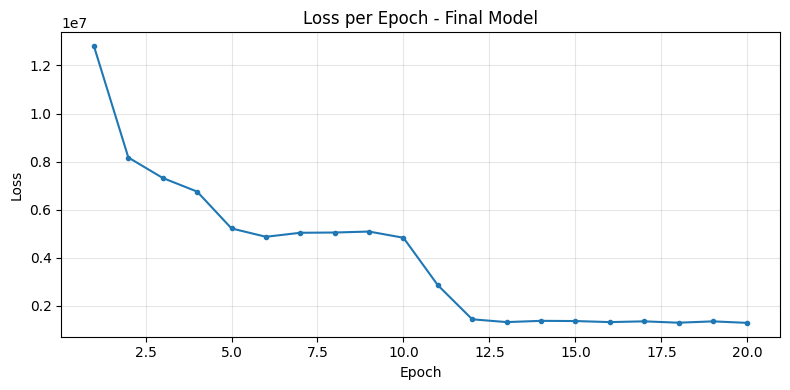

In [ ]:
# FINAL MODEL

FINAL_CONFIG = {
    "vector_size": 100,
    "window":      40,
    "min_count":   5,
    "sg":          1,
    "negative":    20,
    "ns_exponent": 0.75,
    "workers":     4,
    "epochs":      20,
    "seed":        RANDOM_SEED
}

# List for saving logs
training_logs = []

final_model, final_log = train_with_logs(FINAL_CONFIG, train_playlists, label="final_model")
training_logs.append(final_log)

# Save Logs
LOG_PATH = os.path.join(BASE_PATH, "final_model_training_logs.json")
with open(LOG_PATH, "w") as f:
    json.dump(training_logs, f, indent=2)

print(f"Vocabulary size : {len(final_model.wv):,}")
print(f"Logs saved to   : {LOG_PATH}")

# Loss progression
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(final_log["loss_history"]) + 1), final_log["loss_history"], marker="o", markersize=3)
plt.title("Loss per Epoch - Final Model")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "final_model_loss.pdf"), dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
# Save the final model
final_model.save(os.path.join(BASE_PATH, "final_model.model"))

In [8]:
# Reload the final model
final_model = Word2Vec.load(os.path.join(BASE_PATH, "final_model.model"))

# Part C: Evaluation

* **C.1 Next-Song Prediction Task**

In [ ]:
context_results = evaluate_model(final_model, test_playlists, approach="context")
print_results(context_results, "Final Model | Context Averaging")

single_results = evaluate_model(final_model, test_playlists, approach="single")
print_results(single_results, "Final Model | Single Query")

Skipped: 4,970 / 9,426

 Final Model | Context Averaging
K      HR@K         NDCG@K      
------------------------------
5      0.0281       0.0178      
10     0.0491       0.0246      
20     0.0747       0.0311      
50     0.1192       0.0399      
Skipped: 6,436 / 9,426

 Final Model | Single Query
K      HR@K         NDCG@K      
------------------------------
5      0.0559       0.0373      
10     0.0786       0.0446      
20     0.1107       0.0526      
50     0.1515       0.0606      


**C.2 Qualitative Analysis**

In [ ]:
seed_songs = [
    "queen__bohemian rhapsody",           # classic rock
    "led zeppelin__stairway to heaven",   # classic rock
    "michael jackson__thriller",          # pop
    "radiohead__creep",                   # alternative
    "daft punk__one more time",           # electronic
    "eminem__lose yourself",              # hip-hop
    "johnny cash__hurt",                  # country/folk
    "miles davis__so what",               # jazz
]

# FILTER VALID SEED SONGS

valid_seeds = []
invalid_seeds = []

for song in seed_songs:
    if song in final_model.wv:
        valid_seeds.append(song)
    else:
        invalid_seeds.append(song)

print("Valid seeds:", valid_seeds)
print("Missing seeds:", invalid_seeds)

Valid seeds: ['queen__bohemian rhapsody', 'led zeppelin__stairway to heaven', 'michael jackson__thriller', 'radiohead__creep', 'daft punk__one more time', 'eminem__lose yourself', 'johnny cash__hurt', 'miles davis__so what']
Missing seeds: []


In [ ]:
# MOST SIMILAR SONGS

TOP_K = 10

for seed in valid_seeds:
    print(f"\n{'='*60}")
    print(f"Seed: {seed}")
    print(f"{'-'*60}")

    similar_songs = final_model.wv.most_similar(seed, topn=TOP_K)

    for i, (song, score) in enumerate(similar_songs, start=1):
        print(f"{i:2d}. {song:<50} ({score:.4f})")


Seed: queen__bohemian rhapsody
------------------------------------------------------------
 1. queen__we will rock you                            (0.7931)
 2. queen__another one bites the dust                  (0.7897)
 3. queen__don't stop me now                           (0.7868)
 4. queen__killer queen                                (0.7825)
 5. queen__we are the champions                        (0.7564)
 6. queen__bicycle race                                (0.7458)
 7. queen__the show must go on                         (0.7330)
 8. queen__somebody to love                            (0.7194)
 9. queen__i want it all                               (0.7085)
10. queen__brighton rock                               (0.7067)

Seed: led zeppelin__stairway to heaven
------------------------------------------------------------
 1. led zeppelin__whole lotta love                     (0.7674)
 2. led zeppelin__black dog                            (0.7663)
 3. led zeppelin__immigrant song      

In [ ]:
# C.2 SONG ALGEBRA

# Algebra 1: Transfer a Radiohead song to the Beatles.
result = final_model.wv.most_similar(
    positive=["radiohead__creep", "the beatles__let it be"],
    negative=["radiohead__karma police"],
    topn=5
)
print("radiohead__creep - radiohead__karma police + the beatles__let it be =")
for song, score in result:
    print(f"  {song} ({score:.4f})")

print()

# Algebra 2: From Queen to Led Zeppelin
result = final_model.wv.most_similar(
    positive=["queen__bohemian rhapsody", "led zeppelin__stairway to heaven"],
    negative=["queen__we will rock you"],
    topn=5
)
print("queen__bohemian rhapsody - queen__we will rock you + led zeppelin__stairway to heaven =")
for song, score in result:
    print(f"  {song} ({score:.4f})")

print()

# Algebra 3: The transition from Pop to Hip-Hop
result = final_model.wv.most_similar(
    positive=["michael jackson__thriller", "eminem__lose yourself"],
    negative=["michael jackson__bad"],
    topn=5
)
print("michael jackson__thriller - michael jackson__bad + eminem__lose yourself =")
for song, score in result:
    print(f"  {song} ({score:.4f})")

print()

# Algebra 4: Jazz transfer
result = final_model.wv.most_similar(
    positive=["miles davis__so what", "johnny cash__hurt"],
    negative=["miles davis__all blues"],
    topn=5
)
print("miles davis__so what - miles davis__all blues + johnny cash__hurt =")
for song, score in result:
    print(f"  {song} ({score:.4f})")

radiohead__creep - radiohead__karma police + the beatles__let it be =
  the beatles__yesterday (0.7576)
  the beatles__hey jude (0.7256)
  the beatles__help (0.7186)
  the beatles__come together (0.7183)
  the beatles__all you need is love (0.6964)

queen__bohemian rhapsody - queen__we will rock you + led zeppelin__stairway to heaven =
  led zeppelin__black dog (0.6977)
  led zeppelin__whole lotta love (0.6722)
  led zeppelin__immigrant song (0.6379)
  led zeppelin__kashmir (0.6294)
  porcupine tree__arriving somewhere but not here (0.6066)

michael jackson__thriller - michael jackson__bad + eminem__lose yourself =
  eminem__my name is (0.5982)
  eminem__white america (0.5923)
  eminem__the real slim shady (0.5908)
  50 cent__wanksta (0.5908)
  junior stress__znam ten stan (0.5872)

miles davis__so what - miles davis__all blues + johnny cash__hurt =
  nick cave__suzanne (0.5956)
  johnny cash__i walk the line (0.5744)
  johnny cash__desperado (0.5661)
  johnny cash__hey porter (0.5330)

Selected tracks: 972


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


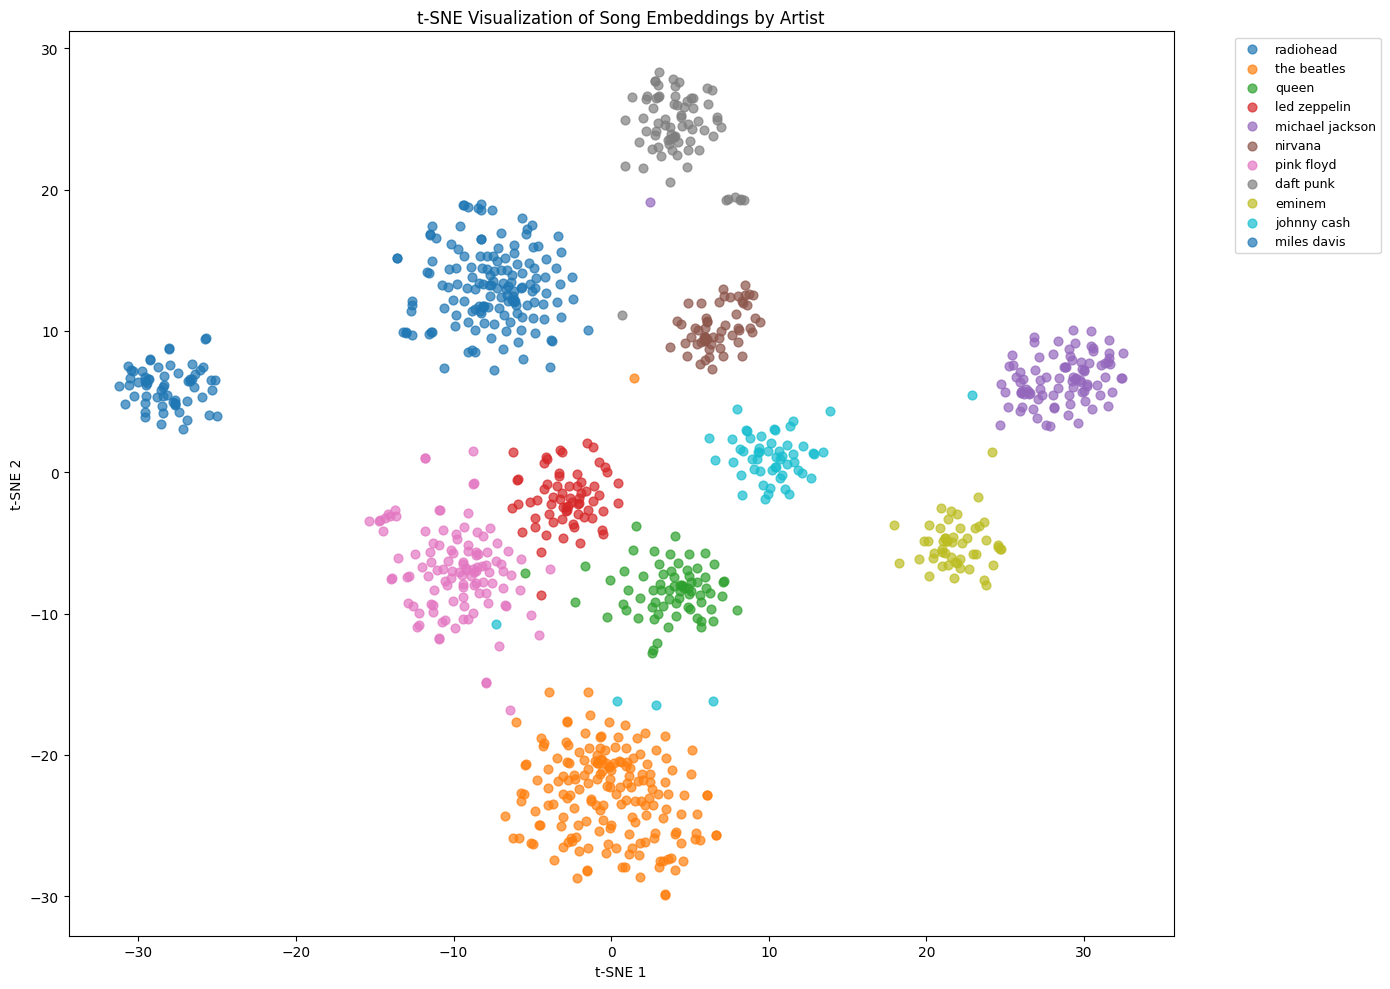

In [ ]:
# C.2 T-SNE VISUALIZATION

# Get all the songs by selected artists
target_artists = [
    "radiohead", "the beatles", "queen", "led zeppelin",
    "michael jackson", "nirvana", "pink floyd", "daft punk",
    "eminem", "johnny cash", "miles davis"
]

selected_tracks = []
selected_artists = []

for track in final_model.wv.index_to_key:
    artist = track.split("__")[0]
    if artist in target_artists:
        selected_tracks.append(track)
        selected_artists.append(artist)

print(f"Selected tracks: {len(selected_tracks):,}")

# Get vectors
vectors = np.array([final_model.wv[track] for track in selected_tracks])

# t-SNE
tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, n_iter=1000)
embeddings_2d = tsne.fit_transform(vectors)

# Color map
artist_to_color = {artist: plt.cm.tab10(i) for i, artist in enumerate(target_artists)}
colors = [artist_to_color[artist] for artist in selected_artists]

# Plot
plt.figure(figsize=(14, 10))
for artist in target_artists:
    mask = [a == artist for a in selected_artists]
    x = embeddings_2d[mask, 0]
    y = embeddings_2d[mask, 1]
    plt.scatter(x, y, label=artist, alpha=0.7, s=40)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=9)
plt.title("t-SNE Visualization of Song Embeddings by Artist")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "tsne_by_artist.pdf"), dpi=300, bbox_inches="tight")
plt.show()

Selected tracks: 972


/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


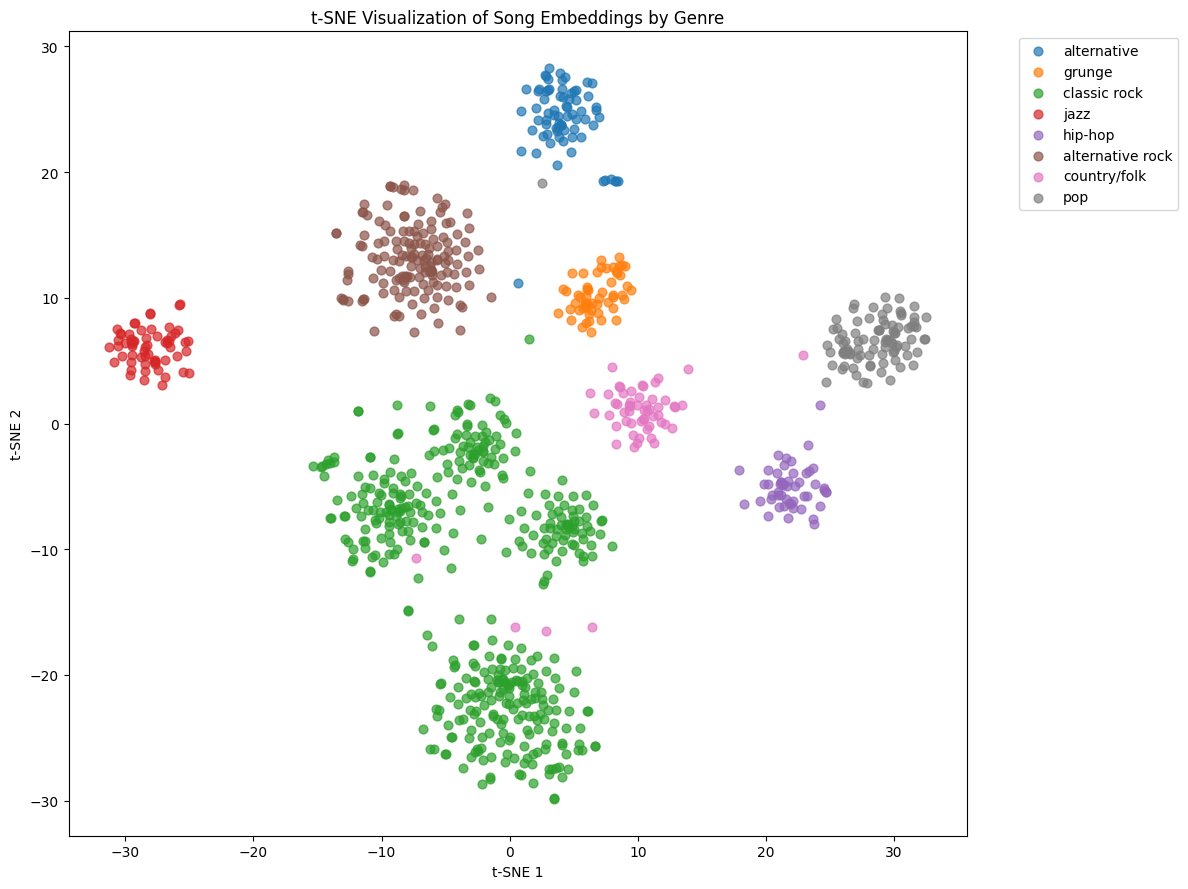

In [ ]:
# C.2 T-SNE VISUALIZATION BY GENRE

artist_to_genre = {
    "radiohead":       "alternative rock",
    "the beatles":     "classic rock",
    "queen":           "classic rock",
    "led zeppelin":    "classic rock",
    "michael jackson": "pop",
    "nirvana":         "grunge",
    "pink floyd":      "classic rock",
    "daft punk":       "alternative",
    "eminem":          "hip-hop",
    "johnny cash":     "country/folk",
    "miles davis":     "jazz",
}

selected_tracks = []
selected_genres = []

for track in final_model.wv.index_to_key:
    artist = track.split("__")[0]
    if artist in artist_to_genre:
        selected_tracks.append(track)
        selected_genres.append(artist_to_genre[artist])

print(f"Selected tracks: {len(selected_tracks):,}")

vectors = np.array([final_model.wv[track] for track in selected_tracks])

tsne = TSNE(n_components=2, random_state=RANDOM_SEED, perplexity=30, n_iter=1000)
embeddings_2d = tsne.fit_transform(vectors)

unique_genres = list(set(selected_genres))
genre_to_color = {genre: plt.cm.tab10(i) for i, genre in enumerate(unique_genres)}
colors = [genre_to_color[genre] for genre in selected_genres]

plt.figure(figsize=(12, 9))
for genre in unique_genres:
    mask = [g == genre for g in selected_genres]
    x = embeddings_2d[mask, 0]
    y = embeddings_2d[mask, 1]
    plt.scatter(x, y, label=genre, alpha=0.7, s=40)

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", fontsize=10)
plt.title("t-SNE Visualization of Song Embeddings by Genre")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.savefig(os.path.join(BASE_PATH, "tsne_by_genre.pdf"), dpi=300, bbox_inches="tight")
plt.show()

# Part D: Recommender System

**D.1 Recommendation Interface**


In [13]:
# RECOMMENDATION INTERFACE

def recommend_songs(seed_songs: List[str], model, top_k: int = 10) -> List[str]:
    """
    Given a list of seed songs, return top_k recommended songs.
    Computes the average embedding of all seed songs that are in the
    vocabulary, then retrieves the most similar songs excluding all
    seed songs (both in-vocab and OOV).

    Args:
        seed_songs : list of track identifiers e.g. ["queen__bohemian rhapsody"]
        model      : trained Word2Vec model
        top_k      : number of recommendations to return

    Returns:
        list of recommended track identifiers
    """
    valid_seeds = [s for s in seed_songs if s in model.wv]

    if not valid_seeds:
        print("None of the seed songs are in the vocabulary.")
        return []

    if len(valid_seeds) < len(seed_songs):
        oov = [s for s in seed_songs if s not in model.wv]
        print(f"OOV seeds skipped: {oov}")

    seed_vector = np.mean([model.wv[s] for s in valid_seeds], axis=0)

    # Keep topn large, filter out all seed_songs.
    similar = model.wv.similar_by_vector(seed_vector, topn=top_k + len(seed_songs))
    recommendations = [
        song for song, score in similar
        if song not in seed_songs  # not valid_seeds, all seed_songs
    ][:top_k]

    return recommendations

# EXAMPLE USAGE

seed_songs = [
    "queen__bohemian rhapsody",           # classic rock
    "led zeppelin__stairway to heaven",   # classic rock
    "michael jackson__thriller",          # pop
    "radiohead__creep",                   # alternative
    "daft punk__one more time",           # electronic
    "eminem__lose yourself",              # hip-hop
    "johnny cash__hurt",                  # country/folk
    "miles davis__so what",               # jazz
]
recs = recommend_songs(seed_songs, final_model, top_k=10)

print(f"Seed songs:")
for s in seed_songs:
    print(f"  {s}")
print(f"\nRecommendations:")
for i, r in enumerate(recs, 1):
    print(f"  {i:2}. {r}")

Seed songs:
  queen__bohemian rhapsody
  led zeppelin__stairway to heaven
  michael jackson__thriller
  radiohead__creep
  daft punk__one more time
  eminem__lose yourself
  johnny cash__hurt
  miles davis__so what

Recommendations:
   1. queen__we will rock you
   2. 50 cent__wanksta
   3. black sabbath__paranoid
   4. red hot chili peppers__californication
   5. queen__another one bites the dust
   6. john lennon__imagine
   7. 2pac__runnin' (dying to live) (feat. the notorious b.i.g.)
   8. eagles__hotel california
   9. lynyrd skynyrd__sweet home alabama
  10. queen__we are the champions


**D.2 Cold-Start Analysis**

In [ ]:
# TRACKS EXCLUDED BY min_count

def analyze_min_count_exclusion(train_playlists, min_count):
    """
    Compute how many unique training tracks are excluded
    because of the min_count threshold.
    """
    train_tracks = [track for pl in train_playlists for track in pl]
    train_counter = Counter(train_tracks)

    total_unique_train_tracks = len(train_counter)
    kept_tracks = {track for track, count in train_counter.items() if count >= min_count}
    excluded_tracks = {track for track, count in train_counter.items() if count < min_count}

    excluded_pct = 100 * len(excluded_tracks) / total_unique_train_tracks
    kept_pct = 100 * len(kept_tracks) / total_unique_train_tracks

    print(f"min_count = {min_count}")
    print(f"Total unique train tracks   : {total_unique_train_tracks:,}")
    print(f"Kept unique tracks          : {len(kept_tracks):,}")
    print(f"Excluded unique tracks      : {len(excluded_tracks):,}")
    print(f"Kept percentage             : {kept_pct:.2f}%")
    print(f"Excluded percentage         : {excluded_pct:.2f}%")

    return {
        "min_count": min_count,
        "total_unique_train_tracks": total_unique_train_tracks,
        "kept_unique_tracks": len(kept_tracks),
        "excluded_unique_tracks": len(excluded_tracks),
        "kept_percentage": kept_pct,
        "excluded_percentage": excluded_pct,
        "train_counter": train_counter,
        "kept_tracks": kept_tracks,
        "excluded_tracks": excluded_tracks
    }


min_count_stats = analyze_min_count_exclusion(train_playlists, min_count=5)

min_count = 5
Total unique train tracks   : 394,510
Kept unique tracks          : 54,651
Excluded unique tracks      : 339,859
Kept percentage             : 13.85%
Excluded percentage         : 86.15%


In [10]:
# UNIQUE-LEVEL OOV RATE
def compute_unique_test_oov_rate(model, test_playlists, train_playlists):
    """
    Compute unique-track OOV rate on the test set, broken down into
    unseen in train vs. seen but below min_count.
    """
    train_vocab = set(track for pl in train_playlists for track in pl)
    test_vocab  = set(track for pl in test_playlists  for track in pl)
    model_vocab = set(model.wv.index_to_key)

    total_unique_test = len(test_vocab)
    in_vocab_unique   = len(test_vocab & model_vocab)
    oov_unique        = total_unique_test - in_vocab_unique

    unseen_in_train   = test_vocab - train_vocab
    seen_but_oov      = (test_vocab & train_vocab) - model_vocab

    print(f"Total unique test tracks         : {total_unique_test:,}")
    print(f"In-vocabulary unique             : {in_vocab_unique:,} ({100*in_vocab_unique/total_unique_test:.2f}%)")
    print(f"OOV unique                       : {oov_unique:,} ({100*oov_unique/total_unique_test:.2f}%)")
    print(f"  ├─ Unseen in train             : {len(unseen_in_train):,} ({100*len(unseen_in_train)/total_unique_test:.2f}%)")
    print(f"  └─ Seen but below min_count    : {len(seen_but_oov):,} ({100*len(seen_but_oov)/total_unique_test:.2f}%)")

    return {
        "total_unique_test":  total_unique_test,
        "in_vocab_unique":    in_vocab_unique,
        "oov_unique":         oov_unique,
        "unseen_in_train":    len(unseen_in_train),
        "seen_but_oov":       len(seen_but_oov),
        "in_vocab_percentage": 100 * in_vocab_unique / total_unique_test,
        "oov_percentage":      100 * oov_unique      / total_unique_test,
    }

unique_oov_stats = compute_unique_test_oov_rate(final_model, test_playlists, train_playlists)

Total unique test tracks         : 162,224
In-vocabulary unique             : 43,015 (26.52%)
OOV unique                       : 119,209 (73.48%)
  ├─ Unseen in train             : 48,674 (30.00%)
  └─ Seen but below min_count    : 70,535 (43.48%)


In [14]:
# ARTIST-LEVEL FALLBACK FOR OOV

def build_artist_index(model):
    """
    Build a mapping from artist name to list of their tracks in vocabulary.
    """
    artist_index = {}
    for track in model.wv.index_to_key:
        artist = track.split("__")[0]
        if artist not in artist_index:
            artist_index[artist] = []
        artist_index[artist].append(track)
    return artist_index

artist_index = build_artist_index(final_model)
print(f"Artists in vocabulary: {len(artist_index):,}")


def recommend_songs_with_fallback(seed_songs: List[str], model, artist_index, top_k: int = 10) -> List[str]:
    """
    Recommend songs with artist-level fallback for OOV seeds.
    For OOV songs, uses the average embedding of the artist's known tracks
    as a proxy embedding.
    """
    valid_vectors = []
    oov_handled = []
    oov_failed = []

    for song in seed_songs:
        if song in model.wv:
            valid_vectors.append(model.wv[song])
        else:
            # Artist-level fallback
            artist = song.split("__")[0]
            if artist in artist_index:
                artist_tracks = artist_index[artist]
                artist_vector = np.mean([model.wv[t] for t in artist_tracks], axis=0)
                valid_vectors.append(artist_vector)
                oov_handled.append(song)
            else:
                oov_failed.append(song)

    if not valid_vectors:
        print("No valid seeds found even after fallback.")
        return []

    if oov_handled:
        print(f"OOV handled via artist fallback : {oov_handled}")
    if oov_failed:
        print(f"OOV failed (artist not found)   : {oov_failed}")

    seed_vector = np.mean(valid_vectors, axis=0)
    similar = model.wv.similar_by_vector(seed_vector, topn=top_k + len(seed_songs))
    recommendations = [
        song for song, score in similar
        if song not in seed_songs
    ][:top_k]

    return recommendations


# Test: daft punk__get lucky OOV but artist is in vocabulary
seeds_with_oov = [
    "queen__bohemian rhapsody",
    "daft punk__get lucky",       # OOV
    "eminem__lose yourself",
]

print("=== Without fallback ===")
recs_no_fallback = recommend_songs(seeds_with_oov, final_model, top_k=5)
for i, r in enumerate(recs_no_fallback, 1):
    print(f"  {i}. {r}")

print("\n=== With artist-level fallback ===")
recs_fallback = recommend_songs_with_fallback(seeds_with_oov, final_model, artist_index, top_k=5)
for i, r in enumerate(recs_fallback, 1):
    print(f"  {i}. {r}")

Artists in vocabulary: 10,858
=== Without fallback ===
OOV seeds skipped: ['daft punk__get lucky']
  1. queen__we are the champions
  2. queen__we will rock you
  3. junior stress__znam ten stan
  4. queen__innuendo
  5. 50 cent__wanksta

=== With artist-level fallback ===
OOV handled via artist fallback : ['daft punk__get lucky']
  1. david guetta__distortion
  2. queen__we are the champions
  3. daft punk__da funk / daftendirekt
  4. queen__we will rock you
  5. 50 cent__wanksta


In [23]:
# HR@10: FREQUENT vs RARE SONGS
def evaluate_by_frequency(model, test_playlists, track_counter,
                           frequent_threshold=100, rare_threshold=10,
                           k=10):
    """
    Compare HR@K for frequent vs rare songs using both evaluation approaches.
    """
    results = {
        "context": {"frequent": [], "rare": []},
        "single":  {"frequent": [], "rare": []}
    }
    skipped = 0

    for playlist in test_playlists:
        if len(playlist) < 2:
            continue

        context   = playlist[:-1]
        true_item = playlist[-1]

        if true_item not in model.wv:
            skipped += 1
            continue

        freq = track_counter.get(true_item, 0)
        if freq > frequent_threshold:
            group = "frequent"
        elif freq < rare_threshold:
            group = "rare"
        else:
            continue  # middle group — don't include

        # Context averaging
        context_in_vocab = [s for s in context if s in model.wv]
        if context_in_vocab:
            context_vector = np.mean([model.wv[s] for s in context_in_vocab], axis=0)
            similar = model.wv.similar_by_vector(context_vector, topn=k)
            recs = [song for song, _ in similar]
            results["context"][group].append(hit_rate_at_k(recs, true_item))

        # Single query
        query_song = context[-1]
        if query_song in model.wv:
            similar = model.wv.most_similar(query_song, topn=k)
            recs = [song for song, _ in similar]
            results["single"][group].append(hit_rate_at_k(recs, true_item))

    print(f"Skipped: {skipped:,}")
    print(f"\n{'─'*55}")
    print(f"{'Group':<20} {'Approach':<20} {'N':>6} {'HR@10':>8}")
    print(f"{'─'*55}")
    for approach in ["context", "single"]:
        for group in ["frequent", "rare"]:
            n = len(results[approach][group])
            hr = np.mean(results[approach][group]) if n > 0 else 0.0
            print(f"{group:<20} {approach:<20} {n:>6} {hr:>8.4f}")
    print(f"{'─'*55}")

    return results

freq_rare_stats = evaluate_by_frequency(
    final_model, test_playlists, track_counter,
    frequent_threshold=100, rare_threshold=10, k=10
)

Skipped: 4,785

───────────────────────────────────────────────────────
Group                Approach                  N    HR@10
───────────────────────────────────────────────────────
frequent             context                 744   0.1304
rare                 context                 660   0.0485
frequent             single                  496   0.1190
rare                 single                  383   0.0601
───────────────────────────────────────────────────────


# Part E: Analysis Report

* **E.1 Failure Analysis**

In [18]:
# FAILURE 1: ARTIST OVER-REPRESENTATION
# Proof: all recommendation for queen__bohemian rhapsody Queen

print("=== BEFORE FIX: Artist Over-Representation ===")
seed = "queen__bohemian rhapsody"
similar = final_model.wv.most_similar(seed, topn=10)
print(f"Seed: {seed}")
print("Recommendations:")
for i, (song, score) in enumerate(similar, 1):
    artist = song.split("__")[0]
    print(f"  {i:2d}. {song:<50} ({score:.4f}) | artist: {artist}")

# How many of the recommendations belong to the same artist?
same_artist = sum(1 for song, _ in similar if song.split("__")[0] == seed.split("__")[0])
print(f"\nSame artist recommendations: {same_artist}/10")

=== BEFORE FIX: Artist Over-Representation ===
Seed: queen__bohemian rhapsody
Recommendations:
   1. queen__we will rock you                            (0.7931) | artist: queen
   2. queen__another one bites the dust                  (0.7897) | artist: queen
   3. queen__don't stop me now                           (0.7868) | artist: queen
   4. queen__killer queen                                (0.7825) | artist: queen
   5. queen__we are the champions                        (0.7564) | artist: queen
   6. queen__bicycle race                                (0.7458) | artist: queen
   7. queen__the show must go on                         (0.7330) | artist: queen
   8. queen__somebody to love                            (0.7194) | artist: queen
   9. queen__i want it all                               (0.7085) | artist: queen
  10. queen__brighton rock                               (0.7067) | artist: queen

Same artist recommendations: 10/10


In [19]:
# FIX: Artist diversity filter — recommend max N from each artist

def recommend_songs_diverse(seed_songs, model, top_k=10, max_per_artist=2):
    """
    Recommend songs with artist diversity constraint.
    At most max_per_artist songs from the same artist are included.
    """
    valid_seeds = [s for s in seed_songs if s in model.wv]

    if not valid_seeds:
        print("None of the seed songs are in the vocabulary.")
        return []

    seed_artists = {s.split("__")[0] for s in seed_songs}
    seed_vector = np.mean([model.wv[s] for s in valid_seeds], axis=0)

    # produce extra recommendations after filtering top_k will remain
    similar = model.wv.similar_by_vector(seed_vector, topn=top_k * 10)

    recommendations = []
    artist_counts = {}

    for song, score in similar:
        if song in seed_songs:
            continue
        artist = song.split("__")[0]
        if artist_counts.get(artist, 0) >= max_per_artist:
            continue
        recommendations.append(song)
        artist_counts[artist] = artist_counts.get(artist, 0) + 1
        if len(recommendations) >= top_k:
            break

    return recommendations


# AFTER FIX
print("=== AFTER FIX: Artist Diversity Filter (max 2 per artist) ===")
seed = "queen__bohemian rhapsody"
recs = recommend_songs_diverse([seed], final_model, top_k=10, max_per_artist=2)
print(f"Seed: {seed}")
print("Recommendations:")
for i, r in enumerate(recs, 1):
    artist = r.split("__")[0]
    print(f"  {i:2d}. {r:<50} | artist: {artist}")

same_artist = sum(1 for r in recs if r.split("__")[0] == seed.split("__")[0])
print(f"\nSame artist recommendations: {same_artist}/10")

=== AFTER FIX: Artist Diversity Filter (max 2 per artist) ===
Seed: queen__bohemian rhapsody
Recommendations:
   1. queen__we will rock you                            | artist: queen
   2. queen__another one bites the dust                  | artist: queen
   3. led zeppelin__stairway to heaven                   | artist: led zeppelin
   4. accept__can't stand the night                      | artist: accept
   5. eagles__hotel california                           | artist: eagles
   6. deep purple__smoke on the water                    | artist: deep purple
   7. guns n' roses__sweet child o' mine                 | artist: guns n' roses
   8. led zeppelin__whole lotta love                     | artist: led zeppelin
   9. dire straits__sultans of swing                     | artist: dire straits
  10. lynyrd skynyrd__sweet home alabama                 | artist: lynyrd skynyrd

Same artist recommendations: 2/10


In [20]:
# FAILURE 2: COLD-START

print("=== BEFORE FIX: Cold-Start Failure ===")
oov_seed = "daft punk__get lucky"
status = "IN vocab" if oov_seed in final_model.wv else "OOV — skipped"
print(f"Seed: {oov_seed} → {status}")
recs_before = recommend_songs(
    ["queen__bohemian rhapsody", oov_seed, "eminem__lose yourself"],
    final_model, top_k=5
)
print("Recommendations (daft punk__get lucky ignored):")
for i, r in enumerate(recs_before, 1):
    print(f"  {i}. {r}")

print()
print("=== AFTER FIX: Artist-Level Fallback ===")
recs_after = recommend_songs_with_fallback(
    ["queen__bohemian rhapsody", oov_seed, "eminem__lose yourself"],
    final_model, artist_index, top_k=5
)
print("Recommendations (daft punk artist embedding used):")
for i, r in enumerate(recs_after, 1):
    print(f"  {i}. {r}")

=== BEFORE FIX: Cold-Start Failure ===
Seed: daft punk__get lucky → OOV — skipped
OOV seeds skipped: ['daft punk__get lucky']
Recommendations (daft punk__get lucky ignored):
  1. queen__we are the champions
  2. queen__we will rock you
  3. junior stress__znam ten stan
  4. queen__innuendo
  5. 50 cent__wanksta

=== AFTER FIX: Artist-Level Fallback ===
OOV handled via artist fallback : ['daft punk__get lucky']
Recommendations (daft punk artist embedding used):
  1. david guetta__distortion
  2. queen__we are the champions
  3. daft punk__da funk / daftendirekt
  4. queen__we will rock you
  5. 50 cent__wanksta


In [26]:
# FAILURE 3: GENRE DRIFT (Dominant genre influence in mixed seeds)

print("=== FAILURE 3: Genre Drift in Mixed-Genre Seeds ===")
print()

mixed_seeds = [
    "queen__bohemian rhapsody",     # classic rock
    "daft punk__one more time",     # electronic
    "eminem__lose yourself",        # hip-hop
]

print("Seed songs:")
for s in mixed_seeds:
    print(f"  {s}")

print()
recs = recommend_songs(mixed_seeds, final_model, top_k=10)
print("Recommendations:")
for i, r in enumerate(recs, 1):
    artist = r.split("__")[0]
    genre_map = {
    # classic rock
    "queen": "classic rock", "led zeppelin": "classic rock",
    "pink floyd": "classic rock", "black sabbath": "classic rock",
    "deep purple": "classic rock", "guns n' roses": "classic rock",
    "eagles": "classic rock", "lynyrd skynyrd": "classic rock",
    "dire straits": "classic rock", "accept": "classic rock",
    # hip-hop / r&b
    "eminem": "hip-hop", "50 cent": "hip-hop", "d12": "hip-hop",
    "kanye west": "hip-hop", "2pac": "hip-hop", "junior stress": "hip-hop",
    "akon": "r&b", "lloyd banks": "hip-hop",
    "black eyed peas": "pop/r&b",
    # electronic
    "daft punk": "electronic", "david guetta": "electronic",
    "eric prydz": "electronic",
    # pop
    "michael jackson": "pop", "ivi adamou": "pop",
    # alternative
    "radiohead": "alternative rock", "nirvana": "grunge",
    # jazz
    "miles davis": "jazz",
    # country/folk
    "johnny cash": "country/folk",
}
    genre = genre_map.get(artist, "unknown")
    print(f"  {i:2d}. {r:<50} | genre: {genre}")

# Count Genre distribution
from collections import Counter
genre_counts = Counter()
for r in recs:
    artist = r.split("__")[0]
    genre_map = {
    # classic rock
    "queen": "classic rock", "led zeppelin": "classic rock",
    "pink floyd": "classic rock", "black sabbath": "classic rock",
    "deep purple": "classic rock", "guns n' roses": "classic rock",
    "eagles": "classic rock", "lynyrd skynyrd": "classic rock",
    "dire straits": "classic rock", "accept": "classic rock",
    # hip-hop / r&b
    "eminem": "hip-hop", "50 cent": "hip-hop", "d12": "hip-hop",
    "kanye west": "hip-hop", "2pac": "hip-hop", "junior stress": "hip-hop",
    "akon": "r&b", "lloyd banks": "hip-hop",
    "black eyed peas": "pop/r&b",
    # electronic
    "daft punk": "electronic", "david guetta": "electronic",
    "eric prydz": "electronic",
    # pop
    "michael jackson": "pop", "ivi adamou": "pop",
    # alternative
    "radiohead": "alternative rock", "nirvana": "grunge",
    # jazz
    "miles davis": "jazz",
    # country/folk
    "johnny cash": "country/folk",
    }
    genre_counts[genre_map.get(artist, "unknown")] += 1

print(f"\nGenre distribution in recommendations:")
for genre, count in genre_counts.most_common():
    print(f"  {genre:<20} : {count}/10")

=== FAILURE 3: Genre Drift in Mixed-Genre Seeds ===

Seed songs:
  queen__bohemian rhapsody
  daft punk__one more time
  eminem__lose yourself

Recommendations:
   1. queen__we will rock you                            | genre: classic rock
   2. akon__smack that (feat. eminem)                    | genre: r&b
   3. 50 cent__wanksta                                   | genre: hip-hop
   4. queen__we are the champions                        | genre: classic rock
   5. lloyd banks__on fire                               | genre: hip-hop
   6. david guetta__distortion                           | genre: electronic
   7. eminem__cleanin' out my closet                     | genre: hip-hop
   8. junior stress__znam ten stan                       | genre: hip-hop
   9. black eyed peas__my humps                          | genre: pop/r&b
  10. ivi adamou__la la love                             | genre: pop

Genre distribution in recommendations:
  hip-hop              : 4/10
  classic rock         :

In [29]:
# FAILURE 4:  Frequency Outlier / Embedding Dilution
print("=== FAILURE 4: Frequency Outlier / Embedding Dilution ===")
most_common_track = track_counter.most_common(1)[0][0]
freq = track_counter[most_common_track]
print(f"Most frequent track: {most_common_track} ({freq:,} occurrences)")
print()

similar = final_model.wv.most_similar(most_common_track, topn=10)
print("Recommendations:")
for i, (song, score) in enumerate(similar, 1):
    song_freq = track_counter.get(song, 0)
    print(f"  {i:2d}. {song:<50} (score: {score:.4f}, freq: {song_freq:,})")

# Average frequency of songs in the recommendation list
rec_freqs = [track_counter.get(song, 0) for song, _ in similar]
print(f"\nAvg frequency of recommended songs : {np.mean(rec_freqs):.0f}")
print(f"Avg frequency of all vocab tracks  : {np.mean(list(track_counter.values())):.0f}")

=== FAILURE 4: Frequency Outlier / Embedding Dilution ===
Most frequent track: zz top__she loves my automobile (31,036 occurrences)

Recommendations:
   1. univers zero__bonjour chez vous                    (score: 0.7495, freq: 5)
   2. john zorn__idalah-abal                             (score: 0.7383, freq: 7)
   3. scuba__suck                                        (score: 0.7207, freq: 8)
   4. nagelfar__schwanengesang                           (score: 0.7192, freq: 5)
   5. the gazette__shiver                                (score: 0.7160, freq: 8)
   6. loscil__chinook                                    (score: 0.7135, freq: 7)
   7. far corner__claws                                  (score: 0.7100, freq: 7)
   8. mahmoud ahmed__bemen sebeb letlash                 (score: 0.7091, freq: 5)
   9. karunesh__blessings rain                           (score: 0.7057, freq: 5)
  10. karunesh__and the grass grows by itself            (score: 0.7052, freq: 7)

Avg frequency of recommended 

In [39]:
# FAILURE 5: LOW SIMILARITY SCORES (Mixed genre seeds)
print("=== FAILURE 5: Low Similarity Scores ===")

mixed_seeds = [
    "queen__bohemian rhapsody",
    "miles davis__so what",
    "eminem__lose yourself",
    "daft punk__one more time",
]

valid_seeds = [s for s in mixed_seeds if s in final_model.wv]
seed_vector = np.mean([final_model.wv[s] for s in valid_seeds], axis=0)
similar = final_model.wv.similar_by_vector(seed_vector, topn=20)

# Filter seed songs
recommendations = [(song, score) for song, score in similar
                   if song not in mixed_seeds][:10]

print("Recommendations (seeds filtered):")
for i, (song, score) in enumerate(recommendations, 1):
    print(f"  {i:2d}. {song:<50} (score: {score:.4f})")

scores = [score for _, score in recommendations]
print(f"\nMean score : {np.mean(scores):.4f}")

scores = [score for _, score in similar]
print(f"\nMin score  : {min(scores):.4f}")
print(f"Max score  : {max(scores):.4f}")
print(f"Mean score : {np.mean(scores):.4f}")

# Comparison: single genre seed
single_genre_similar = final_model.wv.most_similar("queen__bohemian rhapsody", topn=10)
single_scores = [score for _, score in single_genre_similar]
print(f"\nFor comparison — single genre seed (queen__bohemian rhapsody):")
print(f"Min score  : {min(single_scores):.4f}")
print(f"Max score  : {max(single_scores):.4f}")
print(f"Mean score : {np.mean(single_scores):.4f}")

=== FAILURE 5: Low Similarity Scores ===
Recommendations (seeds filtered):
   1. queen__we will rock you                            (score: 0.6785)
   2. 50 cent__wanksta                                   (score: 0.6624)
   3. 50 cent__if i can't                                (score: 0.6433)
   4. lloyd banks__on fire                               (score: 0.6414)
   5. eminem__cleanin' out my closet                     (score: 0.6280)
   6. eminem__the real slim shady                        (score: 0.6255)
   7. queen__we are the champions                        (score: 0.6249)
   8. akon__smack that (feat. eminem)                    (score: 0.6178)
   9. david guetta__distortion                           (score: 0.6174)
  10. kanye west__hell of a life                         (score: 0.6164)

Mean score : 0.6356

Min score  : 0.6076
Max score  : 0.7325
Mean score : 0.6407

For comparison — single genre seed (queen__bohemian rhapsody):
Min score  : 0.7067
Max score  : 0.7931
Mean scor

In [40]:
# FAILURE 6: Cross-Language Recommendation
print("=== FAILURE 6: Cross-Language Recommendation ===")
similar = final_model.wv.most_similar("eminem__lose yourself", topn=10)
for i, (song, score) in enumerate(similar, 1):
    print(f"  {i:2d}. {song:<50} ({score:.4f})")

=== FAILURE 6: Cross-Language Recommendation ===
   1. 50 cent__wanksta                                   (0.6872)
   2. d12__how come                                      (0.6680)
   3. eminem__white america                              (0.6632)
   4. 50 cent__21 questions                              (0.6541)
   5. eminem__cleanin' out my closet                     (0.6532)
   6. junior stress__znam ten stan                       (0.6505)
   7. eminem__mockingbird                                (0.6491)
   8. eminem__superman                                   (0.6485)
   9. kanye west__hell of a life                         (0.6477)
  10. eminem__stan                                       (0.6454)


# Content Specific Questions

Q1. Hyperparameter Analysis: Compare performance for ns_exponent = 0.75 (NLP default) vs. ns_exponent = -0.5 (recommendation setting). Which performs better on your data? Report exact HR@10 values and explain the difference based on track frequency distribution in your dataset.


In [9]:
counts = sorted(track_counter.values(), reverse=True)
print(f"Max occurrence    : {max(counts):,}")
print(f"Top 10 counts     : {counts[:10]}")
print(f"Log10 of max      : {np.log10(max(counts)):.2f}")
print(f"Tracks > 1000     : {sum(1 for c in counts if c > 1000):,}")
print(f"Tracks > 100      : {sum(1 for c in counts if c > 100):,}")
print(f"Tracks > 10       : {sum(1 for c in counts if c > 10):,}")

Max occurrence    : 31,036
Top 10 counts     : [31036, 495, 457, 442, 420, 411, 407, 400, 388, 382]
Log10 of max      : 4.49
Tracks > 1000     : 1
Tracks > 100      : 723
Tracks > 10       : 24,653


Q2. Playlist Length Effect: Split your test playlists into short (<10 songs), medium (10-30 songs), and long (>30 songs). Report HR@10 for each group. Which group shows the best performance and why?

In [12]:
# Q2. PLAYLIST LENGTH EFFECT

def evaluate_by_playlist_length(model, test_playlists, k=10):
    """
    Compare HR@K for short (<10), medium (10-30), and long (>30) playlists.
    Uses both Context Averaging and Single Query approaches.
    """
    results = {
        "short":  {"context": [], "single": []},
        "medium": {"context": [], "single": []},
        "long":   {"context": [], "single": []}
    }
    skipped = 0

    for playlist in test_playlists:
        if len(playlist) < 2:
            continue

        context   = playlist[:-1]
        true_item = playlist[-1]

        if true_item not in model.wv:
            skipped += 1
            continue

        # Playlist length group
        n = len(playlist)
        if n < 10:
            group = "short"
        elif n <= 30:
            group = "medium"
        else:
            group = "long"

        # Context averaging
        context_in_vocab = [s for s in context if s in model.wv]
        if context_in_vocab:
            context_vector = np.mean([model.wv[s] for s in context_in_vocab], axis=0)
            similar = model.wv.similar_by_vector(context_vector, topn=k)
            recs = [song for song, _ in similar]
            results[group]["context"].append(hit_rate_at_k(recs, true_item))

        # Single query
        query_song = context[-1]
        if query_song in model.wv:
            similar = model.wv.most_similar(query_song, topn=k)
            recs = [song for song, _ in similar]
            results[group]["single"].append(hit_rate_at_k(recs, true_item))

    print(f"Skipped: {skipped:,}")
    print(f"\n{'─'*60}")
    print(f"{'Group':<10} {'Approach':<20} {'N':>6} {'HR@10':>8}")
    print(f"{'─'*60}")
    for group in ["short", "medium", "long"]:
        for approach in ["context", "single"]:
            n = len(results[group][approach])
            hr = np.mean(results[group][approach]) if n > 0 else 0.0
            print(f"{group:<10} {approach:<20} {n:>6} {hr:>8.4f}")
    print(f"{'─'*60}")

    return results

length_results = evaluate_by_playlist_length(final_model, test_playlists, k=10)

Skipped: 4,785

────────────────────────────────────────────────────────────
Group      Approach                  N    HR@10
────────────────────────────────────────────────────────────
short      context                1364   0.0762
short      single                 1000   0.0870
medium     context                1684   0.0475
medium     single                 1082   0.0638
long       context                1408   0.0249
long       single                  908   0.0870
────────────────────────────────────────────────────────────


In [13]:
# Number of playlists and length distribution per group
for label, condition in [("short", lambda n: n < 10),
                          ("medium", lambda n: 10 <= n <= 30),
                          ("long", lambda n: n > 30)]:
    group = [pl for pl in test_playlists if condition(len(pl))]
    lengths = [len(pl) for pl in group]
    print(f"{label}: {len(group):,} playlists | avg length: {np.mean(lengths):.1f} | median: {np.median(lengths):.1f}")

short: 3,169 playlists | avg length: 5.0 | median: 5.0
medium: 3,337 playlists | avg length: 17.2 | median: 16.0
long: 2,920 playlists | avg length: 83.4 | median: 65.0


Q3. Vocabulary Coverage: With min_count=5, how many unique tracks are in your vocabulary? What percentage of tracks appearing in your test set are out-of-vocabulary? How does changing min_count to 3 and 10 affect these numbers and HR@10?

In [21]:
# VOCABULARY COVERAGE

train_tracks = [track for pl in train_playlists for track in pl]
train_counter = Counter(train_tracks)
test_vocab = set(track for pl in test_playlists for track in pl)

print(f"Total unique test tracks : {len(test_vocab):,}")
print()

# HR@10 values ​​are from previously run experiments
# This part is hard coded because of runtime disconnection
# min_count_results should be used for reproducibility
hr_results = {
    3:  {"ctx": 0.0178, "sng": 0.0229},
    5:  {"ctx": 0.0251, "sng": 0.0314},
    10: {"ctx": 0.0441, "sng": 0.0656},
}

for mc in [3, 5, 10]:
    mc_vocab = {t for t, c in train_counter.items() if c >= mc}  # unique tracks
    oov = test_vocab - mc_vocab
    oov_pct = 100 * len(oov) / len(test_vocab)

    print(f"min_count = {mc}")
    print(f"  Vocab size (unique train tracks) : {len(mc_vocab):,}")
    print(f"  Test OOV unique                  : {len(oov):,} ({oov_pct:.2f}%)")
    print(f"  HR@10 Context Averaging          : {hr_results[mc]['ctx']:.4f}")
    print(f"  HR@10 Single Query               : {hr_results[mc]['sng']:.4f}")
    print()

Total unique test tracks : 162,224

min_count = 3
  Vocab size (unique train tracks) : 106,476
  Test OOV unique                  : 96,513 (59.49%)
  HR@10 Context Averaging          : 0.0178
  HR@10 Single Query               : 0.0229

min_count = 5
  Vocab size (unique train tracks) : 54,651
  Test OOV unique                  : 119,209 (73.48%)
  HR@10 Context Averaging          : 0.0251
  HR@10 Single Query               : 0.0314

min_count = 10
  Vocab size (unique train tracks) : 21,430
  Test OOV unique                  : 141,950 (87.50%)
  HR@10 Context Averaging          : 0.0441
  HR@10 Single Query               : 0.0656



Q4. Popular vs. Rare: For test playlists ending with a popular song (>100 occurrences in training) vs. rare song (<10 occurrences), what is the difference in HR@10? Does your best model improve performance on rare songs compared to the baseline?

In [26]:
# Popular vs rare
print("=== BASELINE MODEL ===")
baseline_freq_rare = evaluate_by_frequency(
    baseline_model, test_playlists, track_counter,
    frequent_threshold=100, rare_threshold=10, k=10
)

print()
print("=== FINAL MODEL ===")
final_freq_rare = evaluate_by_frequency(
    final_model, test_playlists, track_counter,
    frequent_threshold=100, rare_threshold=10, k=10
)

=== BASELINE MODEL ===
Skipped: 4,785

───────────────────────────────────────────────────────
Group                Approach                  N    HR@10
───────────────────────────────────────────────────────
frequent             context                 744   0.0833
rare                 context                 660   0.0000
frequent             single                  496   0.0685
rare                 single                  383   0.0026
───────────────────────────────────────────────────────

=== FINAL MODEL ===
Skipped: 4,785

───────────────────────────────────────────────────────
Group                Approach                  N    HR@10
───────────────────────────────────────────────────────
frequent             context                 744   0.1304
rare                 context                 660   0.0485
frequent             single                  496   0.1190
rare                 single                  383   0.0601
───────────────────────────────────────────────────────


Q5. Error Patterns: Looking at your failure cases, what is the most common error type? Propose a specific, implementable solution and explain why it would address this error pattern.

In [ ]:
# ================================
# E.1 FAILURE ANALYSIS
# NOTE: Q5 answer is covered by Failure 1 (Artist Over-Representation)
# and its fix (Artist Diversity Filter) implemented in recommend_songs_diverse().
# See Discussion Section 5.5 Error Patterns in the report for the full analysis.
# ================================